# Kirill Burin - 923357830
# Data Analysis of Swedish Leaf Dataset



## Abstract:
The purpose of this project was to identify how leaf species can be analyzed and distinguished based on their features. The analysis was conducted using five leaf species: Ulmus carpinifolia, Alnus incana, Salix sinerea, Tilia, and Fagus silvatica. Each species included 75 leaf samples, giving a total of 375 samples. Since the data were provided as images, the images were first converted to grayscale, and binary masks were then generated for all leaves. Using these masks, shape and outline features, including area, perimeter, aspect ratio, circularity, solidity, and asymmetry, were measured for each leaf. In addition, color-related features based on RGB and HSV values were extracted from the leaf region. The analysis showed that leaf shape and outline provide the main structure for distinguishing species, while color provides additional information for more precise characterization. Therefore, this project was not only a predictive study, but also an analysis of which features best characterize leaf species and what information can and cannot be captured by leaf outlines alone.

## Introduction:
The images of leaves contain several features that can be used to recognize species, including shape, color, and structural properties. However, when deciding which features should be analyzed to distinguish tree species, leaf outline stands out as one of the easiest features to extract from an image and, at the same time, one of the most stable. Compared with color, outline is less affected by factors such as lighting, season, and even the aging of the leaf itself. Compared with structural features, it can also be extracted more easily from a leaf image, even when the image has simply been scanned without any additional processing. Consequently, the use of outline for analysis is justified, especially when describing characteristics such as size, elongation, roundness, lobing, and symmetry. On the other hand, using only outline does not take into account other potentially useful information, such as color. Therefore, color becomes another valuable source of information for examining tree species characteristics.

## Processing:
* Image Reading
The leaf images were read as color images with the file extensions .tif, .tiff, or .png.

* Resizing
If an image was too large, it was resized to a fixed maximum size so that later computations would be more efficient. The resized images were then saved as .png files.

* Conversion to Grayscale
Each RGB image was converted into a grayscale image, meaning that each pixel was represented only by intensity.

* Segmentation of the Leaf from the Background by Thresholding
A threshold value of 200 was used. Pixels with intensity values less than 200 were treated as part of the leaf, while pixels with values greater than 200 were treated as background.

* Removing Noise
Small blob-like artifacts sometimes appeared in the binary image. Connected-component analysis was therefore applied, and only the largest connected component was kept, since it represented the actual leaf.

* Filling Small Holes in the Leaf Image
A filling operation was applied to remove holes inside the segmented leaf region so that the leaf became one complete region.

* Boundary Extraction
The 8-neighborhood rule was used to extract the contour of the leaf. A pixel was considered part of the boundary if it belonged to the leaf and at least one pixel in its 3×3 neighborhood belonged to the background.

* Visual Representation of Intermediate Results
For each leaf image, a four-panel figure was created showing the original color image, grayscale image, binary mask, and extracted contour.

* Centroid
The leaf centroid was obtained from the binary mask of the leaf image, where leaf pixels were represented by 1 and background pixels were represented by 0. After noise removal and hole filling, all pixels belonging to the leaf were identified, and their x- and y-coordinates were collected. The average x-coordinate and the average y-coordinate were then computed, and this point was taken as the centroid of the leaf.


![Leaf 5 processing pipeline](leaf_outputs/intermediate_plots/l5nr018_pipeline.png)
![Leaf 11 processing pipeline](leaf_outputs/intermediate_plots/l11nr040_pipeline.png)

## Outline-based features

The following features were determined from the cleaned binary leaf mask after retaining only the largest connected component and filling holes. The extracted leaf outline was used whenever needed.

### 1. `leaf_area_px`
The total number of pixels in the leaf mask during the center-extraction step.


### 2. `area_px`
The number of pixels in the cleaned leaf mask, expressed in pixel units.

### 3. `perimeter4_raw_px`
The raw perimeter computed using the 4-neighborhood rule (`up`, `down`, `left`, `right`), where each exposed side contributes 1 unit.

### 4. `perimeter8_raw_px`
The raw perimeter computed using an 8-neighborhood approximation, where horizontal and vertical steps have length 1 and diagonal steps have length $\sqrt{2}$.

### 5. `perimeter4_smooth_px`
The perimeter computed after smoothing the mask by opening, closing, and hole filling, followed by application of the same 4-neighborhood rule.

### 6. `length_px`
The estimated leaf length based on PCA, defined as the span of leaf pixels along the major principal axis.

### 7. `width_px`
The estimated leaf width based on PCA, defined as the span of leaf pixels along the minor principal axis.

### 8. `aspect_ratio`
The aspect ratio was computed as

$$
\text{aspect\_ratio} = \frac{\text{length\_px}}{\text{width\_px}}
$$

### 9. `circularity_raw`
The raw circularity was computed as

$$
\text{circularity\_raw} = \frac{4\pi \cdot \text{area\_px}}{(\text{perimeter4\_raw\_px})^2}
$$

### 10. `circularity_smooth`
The smoothed circularity was computed as

$$
\text{circularity\_smooth} = \frac{4\pi \cdot \text{area\_px}}{(\text{perimeter4\_smooth\_px})^2}
$$

### 11. `compactness_raw`
The raw compactness was computed as

$$
\text{compactness\_raw} = \frac{(\text{perimeter4\_raw\_px})^2}{\text{area\_px}}
$$

### 12. `compactness_smooth`
The smoothed compactness was computed as

$$
\text{compactness\_smooth} = \frac{(\text{perimeter4\_smooth\_px})^2}{\text{area\_px}}
$$

### 13. `convex_hull_area_px`
The area, in pixel units, of the smallest convex polygon enclosing all leaf pixels.

### 14. `solidity`
Solidity was computed as

$$
\text{solidity} = \frac{\text{area\_px}}{\text{convex\_hull\_area\_px}}
$$


In [17]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
from PIL import Image
from scipy import ndimage
from scipy.spatial import ConvexHull, QhullError


INPUT_DIR = Path("/Users/kirillburin/Desktop/STA 141B & 160/leaf_images")
OUT_DIR = Path("/Users/kirillburin/Desktop/STA 141B & 160/leaf_outputs")
GRAY_DIR = OUT_DIR / "grayscale"
OUTLINE_DIR = OUT_DIR / "outlines"
CENTERS_CSV = OUT_DIR / "leaf_centers.csv"

GRAY_DIR.mkdir(parents=True, exist_ok=True)
OUTLINE_DIR.mkdir(parents=True, exist_ok=True)

EXTS = {".tif", ".tiff", ".png"}
THRESHOLD = 200
LEAF_IS_DARK = True
S8 = np.ones((3, 3), dtype=bool)


def rgb_to_gray(rgb: np.ndarray) -> np.ndarray:
    gray = (
        0.2989 * rgb[..., 0].astype(np.float32)
        + 0.5870 * rgb[..., 1].astype(np.float32)
        + 0.1140 * rgb[..., 2].astype(np.float32)
    )
    return np.clip(gray, 0, 255).astype(np.uint8)

def make_leaf_mask(gray: np.ndarray, threshold: int = 200, leaf_is_dark: bool = True) -> np.ndarray:
    candidate = gray < threshold if leaf_is_dark else gray > threshold
    labels, n = ndimage.label(candidate, structure=S8)
    if n == 0:
        return np.zeros_like(gray, dtype=bool)
    sizes = np.bincount(labels.ravel())
    sizes[0] = 0
    largest = labels == np.argmax(sizes)
    return ndimage.binary_fill_holes(largest)

def extract_contour(mask: np.ndarray) -> np.ndarray:
    eroded = ndimage.binary_erosion(mask, structure=S8, border_value=0)
    return mask & (~eroded)

def perimeter4(mask: np.ndarray) -> int:
    p = np.pad(mask.astype(bool), 1, mode="constant", constant_values=False)
    c = p[1:-1, 1:-1]
    return int(
        np.sum(c & ~p[:-2, 1:-1]) +
        np.sum(c & ~p[2:, 1:-1]) +
        np.sum(c & ~p[1:-1, :-2]) +
        np.sum(c & ~p[1:-1, 2:])
    )

def perimeter8_from_contour(contour: np.ndarray) -> float:
    c = contour.astype(bool)
    if not c.any():
        return 0.0
    hv = int(np.sum(c[:, :-1] & c[:, 1:]) + np.sum(c[:-1, :] & c[1:, :]))
    diag = int(np.sum(c[:-1, :-1] & c[1:, 1:]) + np.sum(c[:-1, 1:] & c[1:, :-1]))
    return float(hv + math.sqrt(2.0) * diag)

def smooth_mask(mask: np.ndarray, iterations: int = 1) -> np.ndarray:
    m = ndimage.binary_opening(mask, structure=S8, iterations=iterations)
    m = ndimage.binary_closing(m, structure=S8, iterations=iterations)
    m = ndimage.binary_fill_holes(m)
    return m

def length_width_pca(mask: np.ndarray):
    ys, xs = np.where(mask)
    if len(xs) < 2:
        return math.nan, math.nan
    pts = np.column_stack((xs, ys)).astype(np.float64)
    center = pts.mean(axis=0)
    centered = pts - center
    cov = np.cov(centered, rowvar=False)
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = np.argsort(eigvals)[::-1]
    major = eigvecs[:, order[0]]
    minor = eigvecs[:, order[1]]
    proj_major = centered @ major
    proj_minor = centered @ minor
    length = float(proj_major.max() - proj_major.min())
    width = float(proj_minor.max() - proj_minor.min())
    return length, width

def convex_hull_area(mask: np.ndarray):
    ys, xs = np.where(mask)
    if len(xs) < 3:
        return math.nan
    pts = np.column_stack((xs, ys)).astype(np.float64)
    try:
        hull = ConvexHull(pts)
        return float(hull.volume)  
    except QhullError:
        return math.nan

def compute_outline_features(mask: np.ndarray) -> dict:
    area = int(mask.sum())
    if area == 0:
        return {
            "area_px": 0,
            "perimeter4_raw_px": math.nan,
            "perimeter8_raw_px": math.nan,
            "perimeter4_smooth_px": math.nan,
            "length_px": math.nan,
            "width_px": math.nan,
            "aspect_ratio": math.nan,
            "circularity_raw": math.nan,
            "circularity_smooth": math.nan,
            "compactness_raw": math.nan,
            "compactness_smooth": math.nan,
            "convex_hull_area_px": math.nan,
            "solidity": math.nan,
        }

    contour = extract_contour(mask)
    p4_raw = perimeter4(mask)
    p8_raw = perimeter8_from_contour(contour)

    sm = smooth_mask(mask, iterations=1)
    p4_smooth = perimeter4(sm)

    length, width = length_width_pca(mask)
    aspect_ratio = float(length / width) if width > 0 else math.nan

    circularity_raw = float((4 * math.pi * area) / (p4_raw ** 2)) if p4_raw > 0 else math.nan
    circularity_smooth = float((4 * math.pi * area) / (p4_smooth ** 2)) if p4_smooth > 0 else math.nan

    compactness_raw = float((p4_raw ** 2) / area)
    compactness_smooth = float((p4_smooth ** 2) / area)

    hull_area = convex_hull_area(mask)
    solidity = float(area / hull_area) if (not np.isnan(hull_area) and hull_area > 0) else math.nan

    return {
        "area_px": area,
        "perimeter4_raw_px": p4_raw,
        "perimeter8_raw_px": p8_raw,
        "perimeter4_smooth_px": p4_smooth,
        "length_px": length,
        "width_px": width,
        "aspect_ratio": aspect_ratio,
        "circularity_raw": circularity_raw,
        "circularity_smooth": circularity_smooth,
        "compactness_raw": compactness_raw,
        "compactness_smooth": compactness_smooth,
        "convex_hull_area_px": hull_area,
        "solidity": solidity,
    }
image_paths = sorted(
    p for p in INPUT_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in EXTS
)

for p in image_paths:
    rgb = np.array(Image.open(p).convert("RGB"), dtype=np.uint8)
    gray = rgb_to_gray(rgb)
    Image.fromarray(gray).save(GRAY_DIR / f"{p.stem}.png")

print(f"Saved {len(image_paths)} grayscale images to: {GRAY_DIR}")

gray_paths = sorted(GRAY_DIR.glob("*.png"))
print(f"Found {len(gray_paths)} grayscale images.")

for p in gray_paths:
    gray = np.array(Image.open(p).convert("L"), dtype=np.uint8)
    leaf_mask = make_leaf_mask(gray, threshold=THRESHOLD, leaf_is_dark=LEAF_IS_DARK)
    contour = extract_contour(leaf_mask)

    outline_img = np.full(leaf_mask.shape, 255, dtype=np.uint8)
    outline_img[contour] = 0
    Image.fromarray(outline_img).save(OUTLINE_DIR / f"{p.stem}_outline.png")

print(f"Saved {len(gray_paths)} outline images to: {OUTLINE_DIR}")


rows = []
for p in gray_paths:
    gray = np.array(Image.open(p).convert("L"), dtype=np.uint8)
    leaf_mask = make_leaf_mask(gray, threshold=THRESHOLD, leaf_is_dark=LEAF_IS_DARK)

    if not leaf_mask.any():
        rows.append({
            "image_name": p.name,
            "center_x": np.nan,
            "center_y": np.nan,
            "leaf_area_px": 0
        })
        continue

    cy, cx = ndimage.center_of_mass(leaf_mask)
    rows.append({
        "image_name": p.name,
        "center_x": float(cx),
        "center_y": float(cy),
        "leaf_area_px": int(leaf_mask.sum())
    })

centers_df = pd.DataFrame(rows).sort_values("image_name").reset_index(drop=True)
centers_df.to_csv(CENTERS_CSV, index=False)
print(f"Saved centers for {len(centers_df)} images to:\n{CENTERS_CSV}")


centers_df["leaf_group"] = (
    centers_df["image_name"].str.extract(r"(?i)^l(\d+)nr", expand=False).astype("Int64")
)
groups = [1, 5, 11, 13, 15]
centers_df = centers_df[centers_df["leaf_group"].isin(groups)].copy()


features_rows = []
for _, r in centers_df.iterrows():
    image_name = str(r["image_name"])
    gray_path = GRAY_DIR / image_name

    if not gray_path.exists():
        gray_path = GRAY_DIR / (Path(image_name).stem + ".png")

    if not gray_path.exists():
        feat = {k: math.nan for k in [
            "area_px", "perimeter4_raw_px", "perimeter8_raw_px", "perimeter4_smooth_px",
            "length_px", "width_px", "aspect_ratio", "circularity_raw", "circularity_smooth",
            "compactness_raw", "compactness_smooth", "convex_hull_area_px", "solidity"
        ]}
        feat["area_px"] = 0
    else:
        gray = np.array(Image.open(gray_path).convert("L"), dtype=np.uint8)
        mask = make_leaf_mask(gray, threshold=THRESHOLD, leaf_is_dark=LEAF_IS_DARK)
        feat = compute_outline_features(mask)

    feat["image_name"] = image_name
    features_rows.append(feat)

features_df = pd.DataFrame(features_rows)
centers_with_features = centers_df.merge(features_df, on="image_name", how="left")


df_leaf1  = centers_with_features[centers_with_features["leaf_group"] == 1].reset_index(drop=True)
df_leaf5  = centers_with_features[centers_with_features["leaf_group"] == 5].reset_index(drop=True)
df_leaf11 = centers_with_features[centers_with_features["leaf_group"] == 11].reset_index(drop=True)
df_leaf13 = centers_with_features[centers_with_features["leaf_group"] == 13].reset_index(drop=True)
df_leaf15 = centers_with_features[centers_with_features["leaf_group"] == 15].reset_index(drop=True)

Saved 375 grayscale images to: /Users/kirillburin/Desktop/STA 141B & 160/leaf_outputs/grayscale
Found 375 grayscale images.
Saved 375 outline images to: /Users/kirillburin/Desktop/STA 141B & 160/leaf_outputs/outlines
Saved centers for 375 images to:
/Users/kirillburin/Desktop/STA 141B & 160/leaf_outputs/leaf_centers.csv


## Exploratory Data Analysis 
Since more than one leaf from each species was considered, some degree of variation between leaves of the same species was expected. For this reason, exploratory data analysis was performed on each of the outline-based variables prior to interpretation. Summary statistics such as the mean, standard deviation, minimum value, maximum value, median, first quartile, third quartile, and interquartile range were calculated for each variable within each species. Computing these statistics was important because it provided insight into the overall distribution of each variable and helped identify any potential outliers.

In [18]:
df = centers_with_features.copy()
num_cols = df.select_dtypes(include="number").columns.tolist()
num_cols = [c for c in num_cols if c != "leaf_group"]


long_df = (
    df.melt(id_vars="leaf_group", value_vars=num_cols,
            var_name="variable", value_name="value")
    .dropna(subset=["leaf_group", "value"])
)

summary_by_species = (
    long_df.groupby(["leaf_group", "variable"], as_index=False)["value"]
    .agg(
        mean="mean",
        std="std",
        min="min",
        max="max",
        median="median",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75),))

summary_by_species["iqr"] = summary_by_species["q3"] - summary_by_species["q1"]
summary_by_species = summary_by_species[
    ["leaf_group", "variable", "mean", "std", "min", "max", "median", "q1", "q3", "iqr"]
]
summary_by_species.loc[summary_by_species["leaf_group"] == 1]

,leaf_group,variable,mean,std,min,max,median,q1,q3,iqr
0,1,area_px,844755.306667,372710.013252,267694.000000,1.803292e+06,790944.000000,548241.000000,1.118712e+06,570471.000000
1,1,aspect_ratio,1.727776,0.149060,1.377387,2.251894e+00,1.722685,1.636531,1.808462e+00,0.171931
2,1,center_x,523.556096,105.260807,311.920013,8.117680e+02,519.271143,446.177087,5.899568e+02,143.779712
3,1,center_y,853.215276,180.661560,487.677905,1.252560e+03,854.377001,727.348846,1.006715e+03,279.366610
4,1,circularity_raw,0.261765,0.024984,0.167135,3.224679e-01,0.259100,0.250746,2.741300e-01,0.023384
5,1,circularity_smooth,0.312029,0.026668,0.212994,3.767789e-01,0.308719,0.299013,3.256243e-01,0.026611
6,1,compactness_raw,48.474218,5.099565,38.969364,7.518677e+01,48.499999,45.842919,5.011615e+01,4.273226
7,1,compactness_smooth,40.580589,3.717256,33.352105,5.899882e+01,40.704825,38.591715,4.202619e+01,3.434472
8,1,convex_hull_area_px,902358.706667,404325.360980,284066.000000,1.935928e+06,842713.500000,577643.750000,1.229684e+06,652040.500000
9,1,leaf_area_px,844755.306667,372710.013252,267694.000000,1.803292e+06,790944.000000,548241.000000,1.118712e+06,570471.000000


In [19]:
summary_by_species.loc[summary_by_species["leaf_group"] == 5]


,leaf_group,variable,mean,std,min,max,median,q1,q3,iqr
16,5,area_px,174538.493333,53186.717889,82918.000000,318992.000000,172245.000000,134988.000000,204319.500000,69331.500000
17,5,aspect_ratio,2.001596,0.174005,1.545521,2.376874,2.011044,1.878324,2.129925,0.251601
18,5,center_x,281.020810,49.403625,172.787609,479.112658,278.191435,244.886693,309.123566,64.236873
19,5,center_y,387.848206,61.589971,229.526458,570.473112,389.332113,350.308389,421.433580,71.125191
20,5,circularity_raw,0.262997,0.021184,0.223806,0.323252,0.265281,0.245478,0.278690,0.033212
21,5,circularity_smooth,0.279976,0.023612,0.238131,0.344815,0.285176,0.258680,0.296627,0.037947
22,5,compactness_raw,48.088283,3.878044,38.874798,56.148461,47.370119,45.090872,51.192174,6.101301
23,5,compactness_smooth,45.198756,3.802298,36.443837,52.770863,44.065244,42.364290,48.578808,6.214518
24,5,convex_hull_area_px,220609.080000,63831.465620,108650.500000,399647.500000,219168.500000,172482.000000,253214.500000,80732.500000
25,5,leaf_area_px,174538.493333,53186.717889,82918.000000,318992.000000,172245.000000,134988.000000,204319.500000,69331.500000


In [20]:
summary_by_species.loc[summary_by_species["leaf_group"] == 11]

,leaf_group,variable,mean,std,min,max,median,q1,q3,iqr
32,11,area_px,397341.546667,123751.842966,140848.000000,633074.000000,414683.000000,298428.000000,487986.000000,189558.000000
33,11,aspect_ratio,2.104669,0.198115,1.799862,2.832812,2.071864,1.979553,2.177832,0.198279
34,11,center_x,360.053226,56.977948,204.252506,518.784889,366.376247,323.985392,392.911757,68.926365
35,11,center_y,608.204854,97.592937,372.505360,781.936210,624.602856,530.201804,686.060023,155.858218
36,11,circularity_raw,0.295140,0.020991,0.255858,0.349528,0.293885,0.279906,0.309813,0.029907
37,11,circularity_smooth,0.358910,0.020680,0.314857,0.413600,0.362538,0.344646,0.374044,0.029398
38,11,compactness_raw,42.788247,3.011296,35.952444,49.114577,42.759503,40.561159,44.895870,4.334711
39,11,compactness_smooth,35.129332,2.059798,30.382922,39.911308,34.662256,33.596381,36.461693,2.865312
40,11,convex_hull_area_px,422396.560000,128912.269797,151917.000000,666591.000000,445494.000000,317224.500000,518456.500000,201232.000000
41,11,leaf_area_px,397341.546667,123751.842966,140848.000000,633074.000000,414683.000000,298428.000000,487986.000000,189558.000000


In [21]:
summary_by_species.loc[summary_by_species["leaf_group"] == 13]

,leaf_group,variable,mean,std,min,max,median,q1,q3,iqr
48,13,area_px,386732.586667,132128.634527,158632.000000,7.263420e+05,367746.000000,282062.000000,488673.000000,206611.000000
49,13,aspect_ratio,2.085054,0.295649,1.484924,2.970627e+00,2.032149,1.879632,2.241190,0.361558
50,13,center_x,459.374097,83.295576,268.153437,6.750718e+02,459.991881,386.725632,504.164975,117.439343
51,13,center_y,610.540891,101.969500,412.380407,8.767143e+02,614.938496,533.297236,688.798210,155.500973
52,13,circularity_raw,0.184050,0.018367,0.132837,2.201885e-01,0.184138,0.171050,0.198179,0.027130
53,13,circularity_smooth,0.196204,0.018588,0.141894,2.397926e-01,0.195808,0.184701,0.208959,0.024258
54,13,compactness_raw,68.974956,7.159127,57.070958,9.459967e+01,68.244468,63.409082,73.467140,10.058057
55,13,compactness_smooth,64.634759,6.347436,52.405173,8.856198e+01,64.177042,60.138864,68.036252,7.897387
56,13,convex_hull_area_px,609399.446667,209808.094323,265305.000000,1.151558e+06,571511.000000,430127.500000,762819.500000,332692.000000
57,13,leaf_area_px,386732.586667,132128.634527,158632.000000,7.263420e+05,367746.000000,282062.000000,488673.000000,206611.000000


In [22]:
summary_by_species.loc[summary_by_species["leaf_group"] == 15]

,leaf_group,variable,mean,std,min,max,median,q1,q3,iqr
64,15,area_px,532560.920000,153123.592132,154619.000000,9.129010e+05,504776.000000,441393.000000,635206.000000,193813.000000
65,15,aspect_ratio,1.838136,0.138346,1.546218,2.258065e+00,1.814460,1.730199,1.915669,0.185469
66,15,center_x,445.088687,63.196880,261.089898,5.976526e+02,445.195828,403.276061,479.838806,76.562745
67,15,center_y,638.240823,98.408821,360.914726,8.959760e+02,625.260466,586.758307,698.667389,111.909083
68,15,circularity_raw,0.367957,0.021072,0.314717,4.183960e-01,0.368292,0.354891,0.378884,0.023993
69,15,circularity_smooth,0.386271,0.022856,0.326311,4.446496e-01,0.385388,0.372928,0.397892,0.024964
70,15,compactness_raw,34.262405,1.966472,30.034633,3.992905e+01,34.120675,33.167377,35.409157,2.241780
71,15,compactness_smooth,32.643986,1.917306,28.261289,3.851040e+01,32.607033,31.582482,33.696500,2.114019
72,15,convex_hull_area_px,584171.180000,172088.784207,168824.500000,1.011242e+06,547547.000000,476425.750000,704633.750000,228208.000000
73,15,leaf_area_px,532560.920000,153123.592132,154619.000000,9.129010e+05,504776.000000,441393.000000,635206.000000,193813.000000


In [23]:
groups = [1, 5, 11, 13, 15]
compare_by_var = {}

for var in summary_by_species["variable"].unique():
    compare_by_var[var] = (
        summary_by_species.loc[
            summary_by_species["leaf_group"].isin(groups) &
            (summary_by_species["variable"] == var),
            ["leaf_group", "variable", "mean", "median", "std", "min", "max", "iqr"]
        ]
        .sort_values("leaf_group")
        .reset_index(drop=True)
    )

for var, tbl in compare_by_var.items():
    print(f"\n--- {var} ---")
    display(tbl)




--- area_px ---


,leaf_group,variable,mean,median,std,min,max,iqr
0,1,area_px,844755.306667,790944.0,372710.013252,267694.0,1803292.0,570471.0
1,5,area_px,174538.493333,172245.0,53186.717889,82918.0,318992.0,69331.5
2,11,area_px,397341.546667,414683.0,123751.842966,140848.0,633074.0,189558.0
3,13,area_px,386732.586667,367746.0,132128.634527,158632.0,726342.0,206611.0
4,15,area_px,532560.920000,504776.0,153123.592132,154619.0,912901.0,193813.0



--- aspect_ratio ---


,leaf_group,variable,mean,median,std,min,max,iqr
0,1,aspect_ratio,1.727776,1.722685,0.149060,1.377387,2.251894,0.171931
1,5,aspect_ratio,2.001596,2.011044,0.174005,1.545521,2.376874,0.251601
2,11,aspect_ratio,2.104669,2.071864,0.198115,1.799862,2.832812,0.198279
3,13,aspect_ratio,2.085054,2.032149,0.295649,1.484924,2.970627,0.361558
4,15,aspect_ratio,1.838136,1.814460,0.138346,1.546218,2.258065,0.185469



--- center_x ---


...

,leaf_group,variable,mean,median,std,min,max,iqr
0,1,perimeter8_raw_px,11431.902530,11196.808435,3016.150877,6305.929650,19581.084548,5031.810242
1,5,perimeter8_raw_px,5119.247760,5047.232032,748.184211,3669.985207,7239.987658,1040.933116
2,11,perimeter8_raw_px,7524.520570,7705.528855,1292.832453,4640.420849,9965.816444,1950.596680
3,13,perimeter8_raw_px,8835.949986,8461.918682,1722.936824,5667.055408,13136.208722,2584.434342
4,15,perimeter8_raw_px,7925.242286,7745.541049,1339.800226,4351.224889,10849.749560,1894.049999



--- solidity ---


,leaf_group,variable,mean,median,std,min,max,iqr
0,1,solidity,0.938976,0.942611,0.019562,0.835536,0.970242,0.012181
1,5,solidity,0.788370,0.792281,0.031364,0.717274,0.850572,0.045368
2,11,solidity,0.938583,0.938058,0.015070,0.896888,0.963063,0.021633
3,13,solidity,0.635694,0.634551,0.032848,0.551400,0.704442,0.047832
4,15,solidity,0.913228,0.911203,0.015403,0.878089,0.958998,0.019233



--- width_px ---


,leaf_group,variable,mean,median,std,min,max,iqr
0,1,width_px,841.787798,834.374770,179.787074,503.313794,1203.925665,302.902939
1,5,width_px,431.098561,430.571254,69.039547,293.867055,586.853964,91.155966
2,11,width_px,552.124877,574.039130,98.223055,289.364836,728.642996,148.586689
3,13,width_px,719.965912,722.600612,138.266597,431.028932,1024.437765,222.396445
4,15,width_px,705.128023,688.058890,111.755260,368.017375,931.702779,131.845727


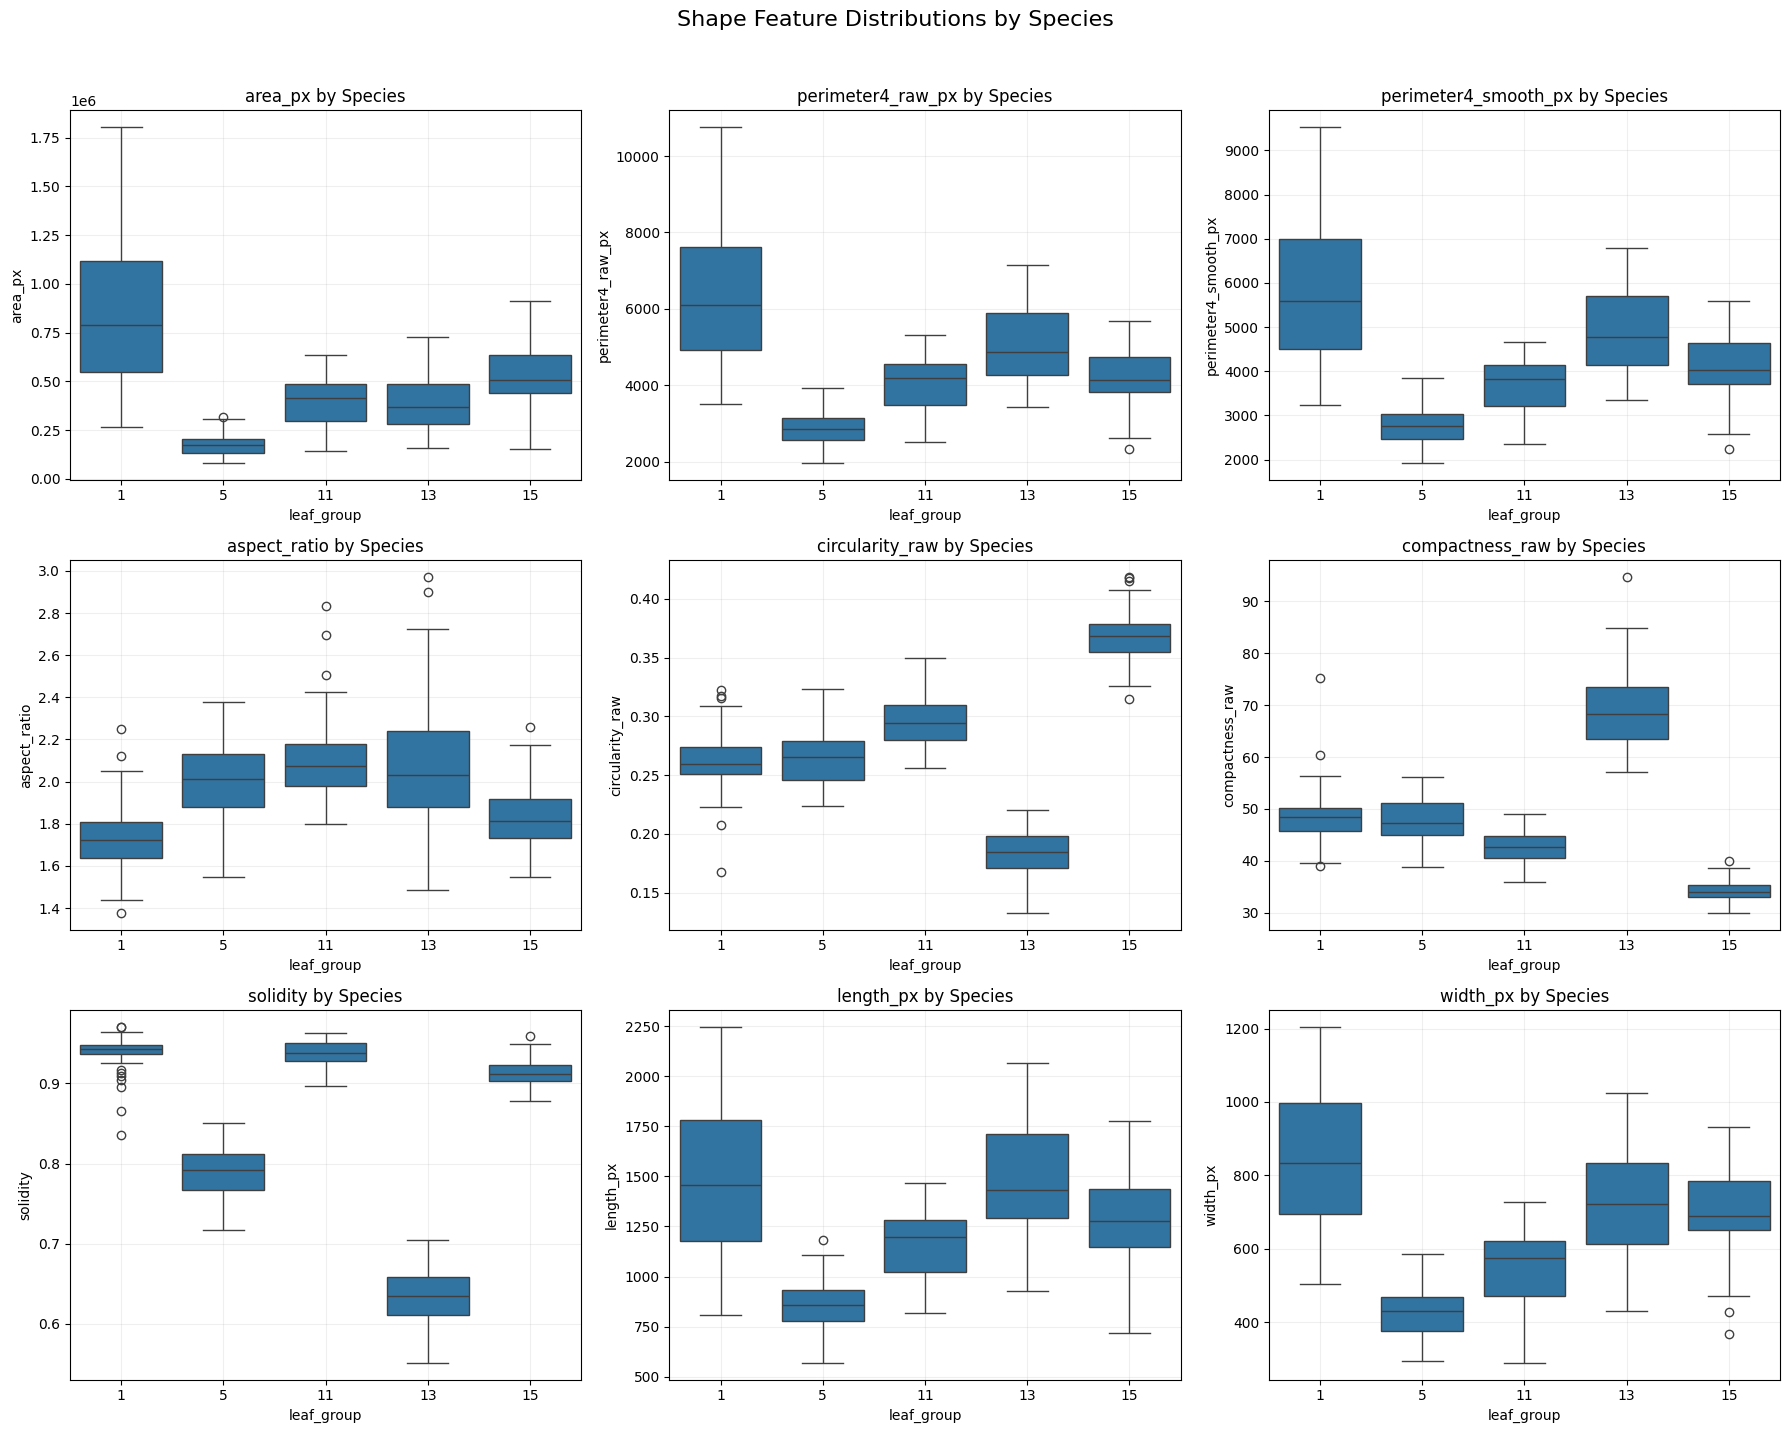

In [24]:

import matplotlib.pyplot as plt
import seaborn as sns

vars_to_plot = [
    "area_px",
    "perimeter4_raw_px",
    "perimeter4_smooth_px",
    "aspect_ratio",
    "circularity_raw",
    "compactness_raw",
    "solidity",
    "length_px",
    "width_px",
]

species_order = [1, 5, 11, 13, 15]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, var in enumerate(vars_to_plot):
    ax = axes[i]
    sns.boxplot(
        data=centers_with_features,
        x="leaf_group",
        y=var,
        order=species_order,
        ax=ax
    )
    ax.set_title(f"{var} by Species")
    ax.set_xlabel("leaf_group")
    ax.set_ylabel(var)
    ax.grid(alpha=0.2)

plt.suptitle("Shape Feature Distributions by Species", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

Key differences (means):

* Area_px: area_px represents the number of pixels in the cleaned leaf mask and therefore measures overall leaf size. The results show clear differences across species: Species 1 has the largest leaf area on average, while Species 5 has the smallest. Species 15 also tends to have relatively large leaves, whereas Species 11 and Species 13 are intermediate between these extremes. In addition, Species 1 has the highest standard deviation and interquartile range, indicating the greatest within-species variability in leaf size.

* Perimeter: total distance around the leaf boundary, and it therefore includes information on both size and boundary shape. Looking at our data, we observe that for all perimeter indices, there is a definite pattern among the species: the highest mean value is for Species 1, while the lowest one is for Species 5, with Species 13, 15, and 11 ranked between these extremes. This means that while having a smaller area, Species 13 has more complex boundaries than some other species. Moreover, the consistency among perimeter indices (raw and smoothed) means that these variations in perimeters cannot be explained solely by noise.

* Length_px: Length describes the span of the leaf along the major principal axis and therefore reflects the overall leaf length. Based on the results, Species 13 has the largest average length, followed very closely by Species 1, while Species 5 has the smallest average length. Species 15 also tends to have relatively long leaves, whereas Species 11 falls between Species 5 and the larger species. In addition, Species 1 shows the greatest variation in length, as indicated by its standard deviation and interquartile range, while Species 5 shows the least variation. Overall, length appears to be a useful variable for distinguishing longer species from shorter ones.

* Width_px: Width describes the span of the leaf along the minor principal axis and therefore reflects how broad the leaf is. Based on the results, Species 1 has the largest average width, while Species 5 has the smallest. Species 13 and Species 15 also tend to have relatively broad leaves, whereas Species 11 is narrower than these two but still wider than Species 5. In addition, Species 1 has the largest standard deviation and interquartile range, indicating greater variation in width within that species. Overall, width appears to be a useful variable for distinguishing broader species from narrower ones.

* aspect_ratio: aspect_ratio describes the relationship between leaf length and leaf width and therefore shows how elongated or broad a leaf is. Based on the results, Species 11 and Species 13 have the highest average aspect ratio values, which indicates that their leaves tend to be the most elongated. Species 5 also has a relatively high aspect ratio, although not as large as Species 11 and 13. In contrast, Species 1 has the lowest average aspect ratio, which suggests that its leaves are broader relative to their length. Species 15 also has a lower aspect ratio compared with Species 5, 11, and 13, meaning that it is less elongated. It should also be noted that Species 13 has the largest standard deviation and interquartile range, indicating greater variability in leaf elongation within that species.

* Circularity: Circularity reflects how similar the leaf contour is to the shape of a circle. In this case, a higher circularity value indicates a more rounded leaf contour, while a lower circularity value indicates a less rounded and more irregular contour. The same general trend can be observed in both the raw and smoothed values. The highest circularity values are observed for Species 15, which implies that the leaves of this species have the most rounded and compact outlines among the five species considered. Species 11 also shows relatively high circularity values. In contrast, Species 1 and Species 5 have lower and fairly similar circularity values. Finally, Species 13 has the lowest circularity values, which indicates that its leaves are the least rounded among all the species considered.

* Compactness: Leaf compactness represents the degree of irregularity of the leaf outline; the higher the compactness value, the more irregular the outline is. A very similar trend can be seen in both the raw and smoothed compactness values. Among the five species considered in the analysis, Species 13 has the highest compactness values, which suggests that it has the most irregular leaf outline. In contrast, Species 15 has the lowest compactness values, meaning that it has the most compact outline. Species 11 also has relatively low compactness, whereas Species 1 and Species 5 fall between these two extremes.

* Convex_hull_area_px: represents the area of the smallest convex shape that can fully enclose the leaf. In general, it reflects the overall spread of the leaf outline while ignoring inward indentations. Based on the results, Species 1 has the largest average convex hull area, while Species 5 has the smallest. Species 13 and Species 15 also have relatively large convex hull areas, whereas Species 11 falls in an intermediate range. In addition, Species 1 shows the greatest variability in convex hull area, as indicated by its large standard deviation and interquartile range. Overall, this variable is useful because it captures differences in the general size and outer spread of the leaf across species.

* Solidity:  measures how completely the leaf fills its convex hull, with higher values indicating a shape that is closer to convex and lower values indicating deeper indentations or a more irregular outline. Based on the results, Species 1 and Species 11 have the highest solidity values, which suggests that their leaves are the least indented and most completely fill their outer shape. Species 15 also has relatively high solidity, although slightly lower than Species 1 and Species 11. In contrast, Species 5 has lower solidity, and Species 13 has the lowest solidity of all five species. This indicates that Species 13 has the deepest indentations and the most irregular outline. Overall, solidity appears to be a useful variable for distinguishing smoother, more filled-out leaves from species with more lobed or irregular shapes.

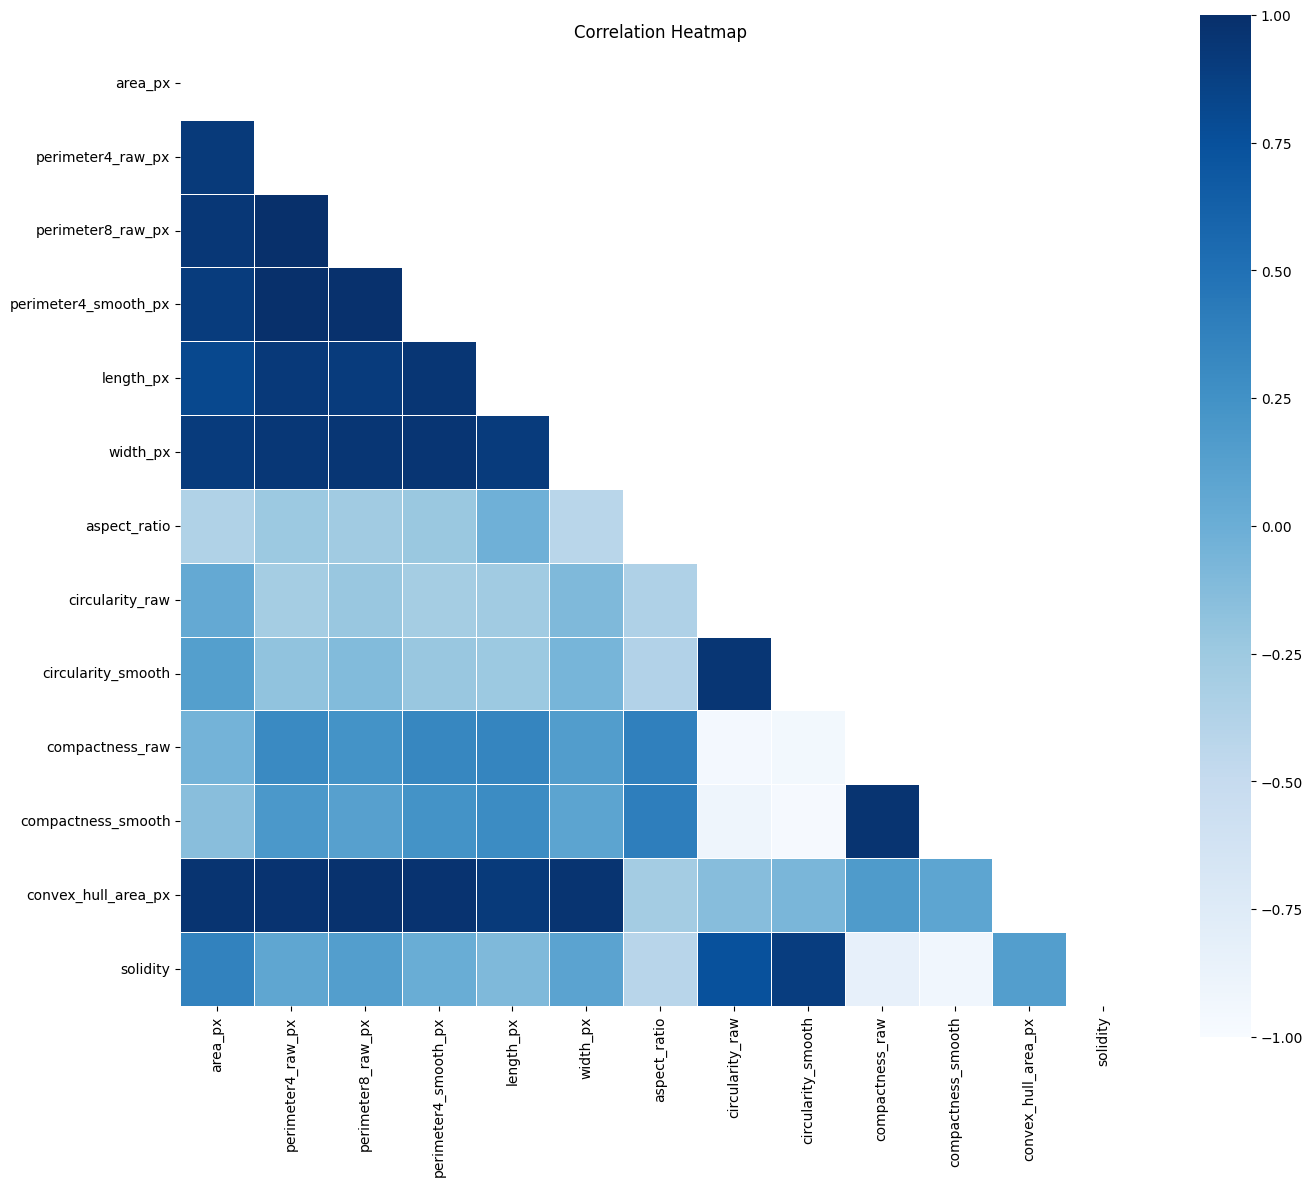

In [25]:
df = centers_with_features.copy()

num_cols = df.select_dtypes(include=np.number).columns.tolist()
drop_cols = ["leaf_group", "center_x", "center_y", "leaf_area_px"]
num_cols = [c for c in num_cols if c not in drop_cols]

corr = df[num_cols].corr(method="pearson")

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    cmap="Blues",   # or "vlag"
    vmin=-1, vmax=1, center=0,
    square=True, linewidths=0.5
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()



From the heatmap, it is clear that several outline parameters are significantly correlated with each other. Area_px, perimeter-related parameters, length_px, width_px, and convex_hull_area_px are highly positively correlated, which implies that they are mainly capturing leaf size rather than shape. Circularity and solidity, which relate to the roundness of the outline, are also very highly correlated, while compactness shows the opposite pattern; higher values correspond to less rounded and more complex outline shapes. Aspect_ratio captures one specific aspect of shape, namely elongation. Last but not least, the high concordance between the raw and smoothed perimeters suggests robust leaf-shape characteristics on the species level.

## Symmetry
Symmetry was included as an outline-based feature to describe how balanced the shape of a leaf is. This is useful because leaves may have similar size but still differ in how evenly their two sides match. To measure symmetry, the centroid of each cleaned leaf mask was first found and used as the center of the leaf. Then, distances from the centroid to the leaf outline were measured at 128 equally spaced points around the leaf, which produced a radial distance curve. By comparing the distances on the left and right sides of this curve, it was possible to measure how symmetric the leaf was. Smaller left-right differences indicated greater symmetry, while larger differences indicated greater asymmetry.

In [26]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
from PIL import Image
from scipy import ndimage

GRAY_DIR = Path("/Users/kirillburin/Desktop/STA 141B & 160/leaf_outputs/grayscale")
OUT_CURVES = Path("/Users/kirillburin/Desktop/STA 141B & 160/leaf_outputs/leaf_curves_128.csv")
OUT_SYM = Path("/Users/kirillburin/Desktop/STA 141B & 160/leaf_outputs/species_symmetry_summary.csv")

THRESHOLD = 200
LEAF_IS_DARK = True
N_ANGLES = 128
S8 = np.ones((3, 3), dtype=bool)

def clean_leaf_mask(gray, threshold=200, leaf_is_dark=True):
    candidate = gray < threshold if leaf_is_dark else gray > threshold
    labels, n = ndimage.label(candidate, structure=S8)
    if n == 0:
        return np.zeros_like(gray, dtype=bool)
    sizes = np.bincount(labels.ravel())
    sizes[0] = 0
    mask = labels == np.argmax(sizes)
    return ndimage.binary_fill_holes(mask)

def pca_center_and_axis(mask):
    ys, xs = np.where(mask)
    pts = np.column_stack((xs, ys)).astype(float)
    center = pts.mean(axis=0)  # (cx, cy)

    centered = pts - center
    cov = np.cov(centered, rowvar=False)
    eigvals, eigvecs = np.linalg.eigh(cov)
    major = eigvecs[:, np.argmax(eigvals)]
    minor = eigvecs[:, np.argmin(eigvals)]

    t = centered @ major
    u = centered @ minor
    q = 0.08
    lo = t <= np.quantile(t, q)
    hi = t >= np.quantile(t, 1 - q)
    w_lo = np.mean(np.abs(u[lo])) if np.any(lo) else np.inf
    w_hi = np.mean(np.abs(u[hi])) if np.any(hi) else np.inf

 
    stem_to_tip = major if w_hi < w_lo else -major
    return center, stem_to_tip

def rotate_mask_tip_up(mask, stem_to_tip):
    
    angle_now = np.degrees(np.arctan2(stem_to_tip[1], stem_to_tip[0]))  
    angle_target = -90.0  # up
    rot_deg = angle_target - angle_now

    rot = ndimage.rotate(
        mask.astype(np.uint8),
        rot_deg,
        reshape=True,
        order=0,
        mode="constant",
        cval=0
    ) > 0
    center_rot = ndimage.center_of_mass(rot)
    center_rot = (float(center_rot[1]), float(center_rot[0]))  
    return rot, center_rot

def extract_contour(mask):
    er = ndimage.binary_erosion(mask, structure=S8, border_value=0)
    return mask & (~er)

def radial_signature_from_contour(mask, center, n_angles=128):
    contour = extract_contour(mask)
    ys, xs = np.where(contour)
    if len(xs) < 20:
        return None, None

    cx, cy = center
    dx = xs - cx
    dy = ys - cy

    
    ang = np.arctan2(dx, -dy)  
    r = np.sqrt(dx**2 + dy**2)

    edges = np.linspace(-np.pi, np.pi, n_angles + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])

    idx = np.digitize(ang, edges) - 1
    idx[idx == n_angles] = n_angles - 1

    sig = np.full(n_angles, np.nan)
    for k in range(n_angles):
        m = idx == k
        if np.any(m):
            sig[k] = np.max(r[m])

    valid = ~np.isnan(sig)
    if valid.sum() < 3:
        return None, None

    
    a_ext = np.r_[centers[valid] - 2*np.pi, centers[valid], centers[valid] + 2*np.pi]
    r_ext = np.r_[sig[valid], sig[valid], sig[valid]]
    sig = np.interp(centers, a_ext, r_ext)
    return centers, sig

def symmetry_error_from_curve(angles, sig):
    a_ext = np.r_[angles - 2*np.pi, angles, angles + 2*np.pi]
    r_ext = np.r_[sig, sig, sig]
    r_mirror = np.interp(-angles, a_ext, r_ext)
    err = np.mean(np.abs(sig - r_mirror) / (sig + r_mirror + 1e-9))
    return float(err)

def parse_leaf_group(name):
    m = re.match(r"(?i)^l(\d+)nr", name)
    return int(m.group(1)) if m else np.nan


rows = []
for p in sorted(GRAY_DIR.glob("*.png")):
    gray = np.array(Image.open(p).convert("L"), dtype=np.uint8)
    mask = clean_leaf_mask(gray, threshold=THRESHOLD, leaf_is_dark=LEAF_IS_DARK)

    if not mask.any():
        continue

    center, stem_to_tip = pca_center_and_axis(mask)
    mask_aligned, center_aligned = rotate_mask_tip_up(mask, stem_to_tip)
    angles, curve = radial_signature_from_contour(mask_aligned, center_aligned, n_angles=N_ANGLES)

    if curve is None:
        continue

    sym_err = symmetry_error_from_curve(angles, curve)

    row = {
        "image_name": p.name,
        "leaf_group": parse_leaf_group(p.name),
        "symmetry_error": sym_err
    }
    for i, d in enumerate(curve):
        row[f"d_{i:03d}"] = float(d)

    rows.append(row)

curve_df = pd.DataFrame(rows).sort_values(["leaf_group", "image_name"]).reset_index(drop=True)
curve_df.to_csv(OUT_CURVES, index=False)

sym_summary = (
    curve_df.groupby("leaf_group", as_index=False)["symmetry_error"]
    .agg(mean="mean", median="median", std="std", min="min", max="max")
    .sort_values("mean")
)
sym_summary.to_csv(OUT_SYM, index=False)

print(f"Saved curves: {OUT_CURVES} (rows={len(curve_df)})")
print(f"Saved symmetry summary: {OUT_SYM}")
sym_summary

Saved curves: /Users/kirillburin/Desktop/STA 141B & 160/leaf_outputs/leaf_curves_128.csv (rows=375)
Saved symmetry summary: /Users/kirillburin/Desktop/STA 141B & 160/leaf_outputs/species_symmetry_summary.csv


,leaf_group,mean,median,std,min,max
1,5,0.056779,0.052231,0.022921,0.017572,0.115547
4,15,0.060265,0.057954,0.029250,0.018938,0.140054
2,11,0.066314,0.053324,0.046433,0.006218,0.223334
3,13,0.071189,0.071158,0.027318,0.014929,0.127577
0,1,0.081166,0.084227,0.034665,0.010534,0.148218


The variable symmetry_error measures the difference between the left and right sides of the leaf, so lower values indicate greater symmetry and higher values indicate greater asymmetry. Based on the results, Species 5 has the lowest average symmetry error and is therefore the most symmetric species on average, followed by Species 15. Species 11 and Species 13 show intermediate levels of symmetry, while Species 1 has the highest average symmetry error and is therefore the least symmetric on average. In terms of variability, Species 11 has the largest standard deviation and maximum value, which suggests that its leaves vary widely in symmetry, with some leaves being quite balanced and others much more asymmetric. Species 13 shows a mean and median that are very close to each other, which suggests a more stable level of asymmetry across that species. Overall, symmetry appears to be a useful feature for distinguishing species, since some groups, such as Species 5 and Species 15, tend to be more balanced, while Species 1 tends to be less symmetric.

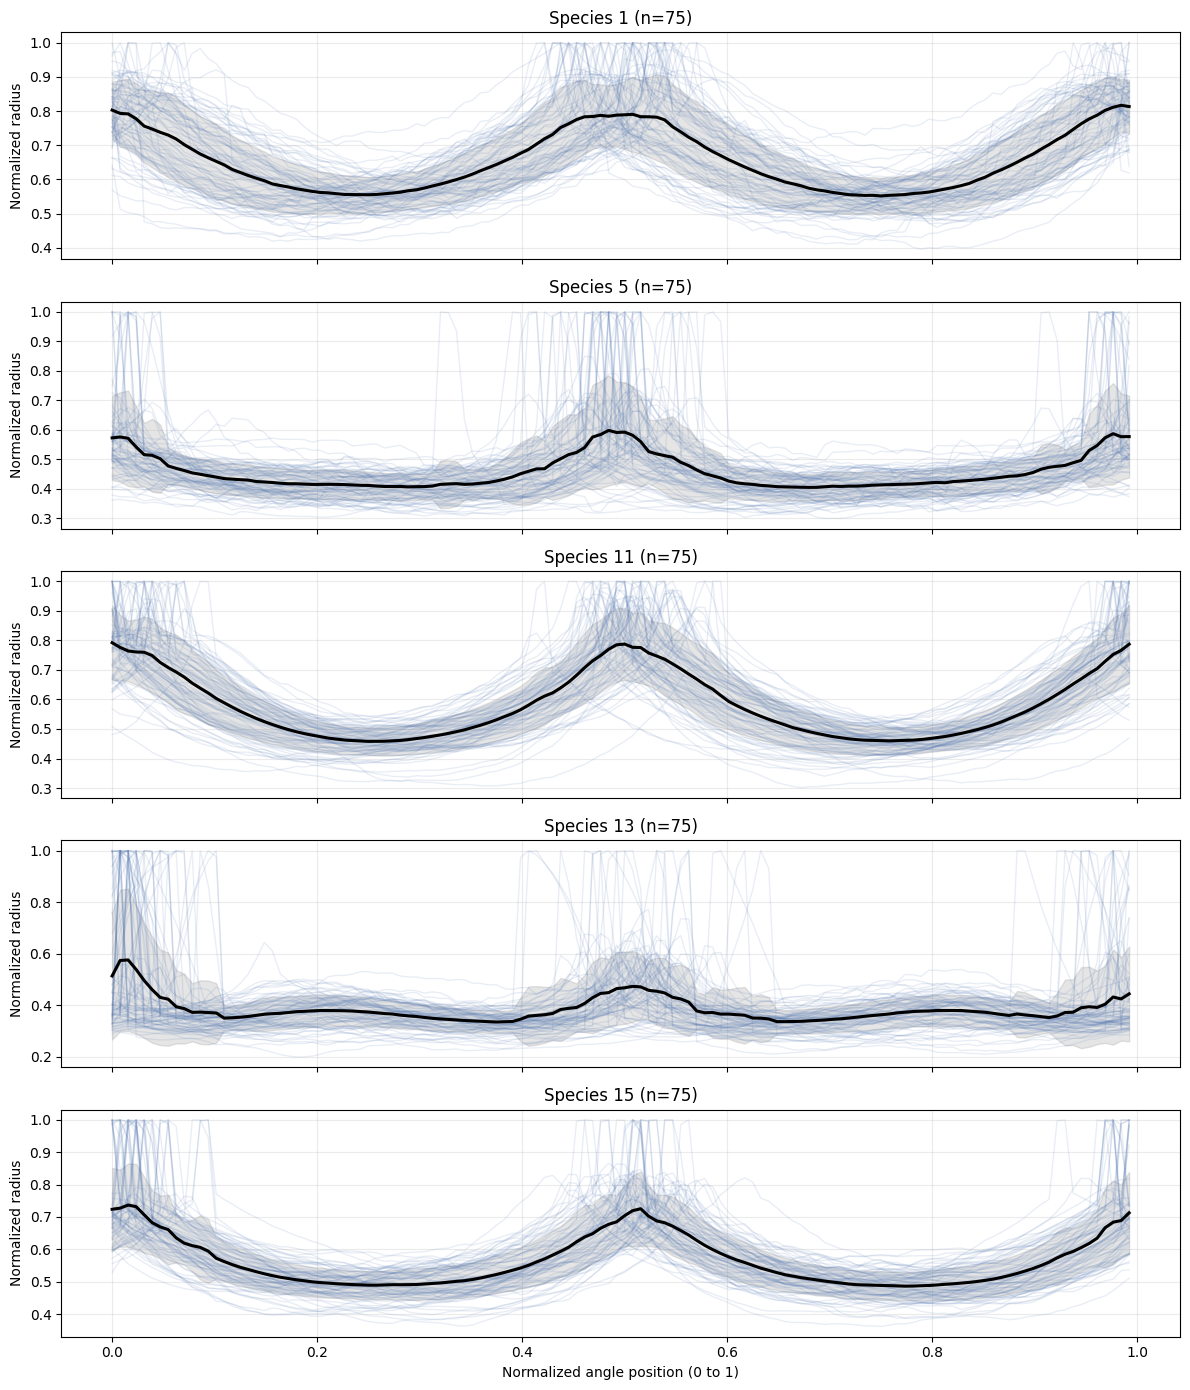

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


if "curve_df" not in globals():
    curve_df = pd.read_csv("/Users/kirillburin/Desktop/STA 141B & 160/leaf_outputs/leaf_curves_128.csv")

dist_cols = sorted([c for c in curve_df.columns if c.startswith("d_")])
species_order = [1, 5, 11, 13, 15]


x = np.linspace(0, 1, len(dist_cols), endpoint=False)


NORMALIZE_EACH_CURVE = True

fig, axes = plt.subplots(5, 1, figsize=(12, 14), sharex=True)

for ax, g in zip(axes, species_order):
    sub = curve_df[curve_df["leaf_group"] == g].copy()
    Y = sub[dist_cols].to_numpy(dtype=float)

    if NORMALIZE_EACH_CURVE:
        Y = Y / (Y.max(axis=1, keepdims=True) + 1e-9)


    for i in range(Y.shape[0]):
        ax.plot(x, Y[i], color="#4C72B0", alpha=0.12, linewidth=1.0)


    mean_y = Y.mean(axis=0)
    std_y = Y.std(axis=0)
    ax.plot(x, mean_y, color="black", linewidth=2.2, label="Mean")
    ax.fill_between(x, mean_y - std_y, mean_y + std_y, color="gray", alpha=0.20, label="±1 SD")

    ax.set_title(f"Species {g} (n={len(sub)})")
    ax.set_ylabel("Normalized radius" if NORMALIZE_EACH_CURVE else "Radius")
    ax.grid(alpha=0.25)

axes[-1].set_xlabel("Normalized angle position (0 to 1)")
plt.tight_layout()
plt.show()

The radial distance curves provide a visual way to study leaf symmetry. For each species, distances from the centroid to the leaf boundary were measured at 128 equally spaced angular positions, producing one curve for each leaf. A more symmetric leaf is expected to have two halves of the curve that are more similar to one another. Based on the plots, Species 5 and Species 15 show the most balanced average curves, which is consistent with their lower symmetry error values. In contrast, Species 1 shows the greatest left-right imbalance on average. Species 11 appears to have the greatest variability in symmetry, meaning that some leaves are quite balanced while others are more asymmetric. Species 13 lies between these extremes and appears to show a more consistently asymmetric outline.

## Color Analysis
Color analysis was included to determine whether leaf color provides useful information in addition to shape and outline. In this step, color was analyzed only on the leaf region, not on the white background. After the leaf mask had been obtained from the preprocessing stage, the RGB channels of the original color image were extracted, and only the pixels belonging to the cleaned leaf mask were kept. These leaf pixels were then converted from RGB to HSV, since HSV is often easier to interpret than RGB. In the HSV system, Hue describes the general color type, Saturation describes how vivid or pure the color is, and Value describes brightness, with higher values corresponding to lighter colors. Summary statistics such as means and standard deviations were then computed for the RGB and HSV values, and histograms were used to examine the distribution of color within each leaf. This made it possible to compare whether different species tended to have systematically different color patterns, and whether color within a species was relatively uniform or highly variable.

In [28]:
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
from matplotlib.colors import rgb_to_hsv


BASE_DIR = Path("/Users/kirillburin/Desktop/STA 141B & 160")
ORIG_DIR = BASE_DIR / "leaf_images"                 
GRAY_DIR = BASE_DIR / "leaf_outputs" / "grayscale"  
OUT_DIR = BASE_DIR / "leaf_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)


if "make_leaf_mask" not in globals():
    raise RuntimeError("make_leaf_mask(...) not found. Run your mask/shape cells first.")
if "centers_with_features" not in globals():
    raise RuntimeError("centers_with_features not found. Run your shape-feature cells first.")

shape_df = centers_with_features.copy()


orig_paths = []
for ext in ("*.tif", "*.tiff", "*.png", "*.jpg", "*.jpeg"):
    orig_paths.extend(ORIG_DIR.rglob(ext))

stem_to_orig = {}
for p in orig_paths:
    stem_to_orig.setdefault(p.stem.lower(), p)  

def rgb_to_gray_uint8(rgb):

    gray = (
        0.2989 * rgb[..., 0].astype(np.float32)
        + 0.5870 * rgb[..., 1].astype(np.float32)
        + 0.1140 * rgb[..., 2].astype(np.float32)
    )
    return np.clip(gray, 0, 255).astype(np.uint8)

def load_rgb_and_mask(image_name, threshold=200, leaf_is_dark=True):

    stem = Path(image_name).stem
    key = stem.lower()

    if key not in stem_to_orig:
        raise FileNotFoundError(f"No original image found for stem '{stem}' in {ORIG_DIR}")

    rgb = np.array(Image.open(stem_to_orig[key]).convert("RGB"), dtype=np.uint8)

    gray_path = GRAY_DIR / f"{stem}.png"
    if gray_path.exists():
        gray = np.array(Image.open(gray_path).convert("L"), dtype=np.uint8)
    else:
        gray = rgb_to_gray_uint8(rgb)

    mask = make_leaf_mask(gray, threshold=threshold, leaf_is_dark=leaf_is_dark)


    if mask.shape != rgb.shape[:2]:
        nearest = getattr(getattr(Image, "Resampling", Image), "NEAREST")
        mask_img = Image.fromarray((mask.astype(np.uint8) * 255))
        mask = np.array(mask_img.resize((rgb.shape[1], rgb.shape[0]), resample=nearest), dtype=np.uint8) > 0

    return rgb, mask

def get_leaf_pixels_rgb_hsv(image_name, threshold=200, leaf_is_dark=True):
    rgb, mask = load_rgb_and_mask(image_name, threshold=threshold, leaf_is_dark=leaf_is_dark)
    leaf_rgb = rgb[mask]
    if leaf_rgb.size == 0:
        return leaf_rgb, np.empty((0, 3), dtype=np.float32)
    leaf_hsv = rgb_to_hsv(leaf_rgb.astype(np.float32) / 255.0)
    return leaf_rgb, leaf_hsv

def compute_leaf_color_features(image_name, threshold=200, leaf_is_dark=True):
    """
    Compute RGB + HSV summary stats from leaf pixels only.
    One row per leaf image.
    """
    leaf_rgb, leaf_hsv = get_leaf_pixels_rgb_hsv(
        image_name,
        threshold=threshold,
        leaf_is_dark=leaf_is_dark
    )

    if leaf_rgb.size == 0:
        return {
            "image_name": image_name,
            "leaf_pixel_count": 0,
            "mean_R": np.nan, "mean_G": np.nan, "mean_B": np.nan,
            "std_R": np.nan, "std_G": np.nan, "std_B": np.nan,
            "mean_H": np.nan, "mean_S": np.nan, "mean_V": np.nan,
            "std_H": np.nan, "std_S": np.nan, "std_V": np.nan,
        }

    R = leaf_rgb[:, 0].astype(np.float32)
    G = leaf_rgb[:, 1].astype(np.float32)
    B = leaf_rgb[:, 2].astype(np.float32)
    H = leaf_hsv[:, 0]
    S = leaf_hsv[:, 1]
    V = leaf_hsv[:, 2]

    return {
        "image_name": image_name,
        "leaf_pixel_count": int(leaf_rgb.shape[0]),
        "mean_R": float(np.mean(R)), "mean_G": float(np.mean(G)), "mean_B": float(np.mean(B)),
        "std_R": float(np.std(R)),   "std_G": float(np.std(G)),   "std_B": float(np.std(B)),
        "mean_H": float(np.mean(H)), "mean_S": float(np.mean(S)), "mean_V": float(np.mean(V)),
        "std_H": float(np.std(H)),   "std_S": float(np.std(S)),   "std_V": float(np.std(V)),
    }


color_rows = []
for image_name in shape_df["image_name"].astype(str):
    color_rows.append(compute_leaf_color_features(image_name, threshold=200, leaf_is_dark=True))

color_features_df = pd.DataFrame(color_rows).sort_values("image_name").reset_index(drop=True)


color_features_df["leaf_group"] = pd.to_numeric(
    color_features_df["image_name"].str.extract(r"(?i)^l(\d+)nr", expand=False),
    errors="coerce"
).astype("Int64")

shape_without_color_cols = shape_df.drop(
    columns=[c for c in color_features_df.columns if c != "image_name" and c in shape_df.columns],
    errors="ignore"
)
shape_color_df = shape_without_color_cols.merge(color_features_df, on="image_name", how="left")

color_features_df.to_csv(OUT_DIR / "leaf_color_features.csv", index=False)
shape_color_df.to_csv(OUT_DIR / "leaf_shape_color_features.csv", index=False)

print("Saved:", OUT_DIR / "leaf_color_features.csv")
print("Saved:", OUT_DIR / "leaf_shape_color_features.csv")
shape_color_df

Saved: /Users/kirillburin/Desktop/STA 141B & 160/leaf_outputs/leaf_color_features.csv
Saved: /Users/kirillburin/Desktop/STA 141B & 160/leaf_outputs/leaf_shape_color_features.csv


,image_name,center_x,center_y,leaf_area_px,area_px,perimeter4_raw_px,perimeter8_raw_px,perimeter4_smooth_px,length_px,width_px,...,std_R,std_G,std_B,mean_H,mean_S,mean_V,std_H,std_S,std_V,leaf_group
0,l11nr001.png,449.070302,692.122744,509647,509647,4794,8928.059951,4338,1272.790742,660.517654,...,24.353022,25.030731,24.689701,0.160166,0.802492,0.269751,0.040838,0.219653,0.097178,11
1,l11nr002.png,377.995985,639.555472,417913,417913,4268,7765.048625,3940,1231.201882,594.944120,...,25.866812,24.454599,25.863363,0.179329,0.822189,0.325550,0.040081,0.197781,0.099127,11
2,l11nr003.png,350.302618,530.984726,254093,254093,3444,6451.073878,3012,943.674491,441.878614,...,26.491890,25.253468,27.513063,0.175893,0.869488,0.304926,0.029357,0.216193,0.101763,11
3,l11nr004.png,366.376247,537.388897,346251,346251,3934,7216.289173,3426,1027.044807,509.896989,...,23.866980,24.590462,26.029097,0.162369,0.855532,0.260348,0.042695,0.209323,0.096414,11
4,l11nr005.png,378.459765,529.418882,394791,394791,4254,7718.480082,3746,1077.165098,592.938283,...,21.745117,23.239035,19.650150,0.153805,0.959148,0.244135,0.035297,0.146076,0.087597,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
370,l5nr071.png,270.156880,367.375109,168415,168415,2812,5022.173157,2690,827.968699,430.571254,...,33.240204,30.211180,26.868153,0.179484,0.909843,0.284486,0.042628,0.196447,0.125140,5
371,l5nr072.png,376.687793,493.151749,270295,270295,3500,6145.478857,3392,1017.369445,543.228444,...,28.019857,27.864645,26.337467,0.155020,0.891246,0.273105,0.038929,0.201490,0.111246,5
372,l5nr073.png,305.361524,406.725929,208979,208979,2968,5233.126476,2894,884.005416,499.130499,...,26.463171,26.215197,28.496544,0.159908,0.833622,0.295668,0.034301,0.229131,0.105846,5
373,l5nr074.png,267.623547,350.600438,163096,163096,2518,4380.590329,2438,732.953476,429.352419,...,27.472099,25.691729,29.255268,0.171843,0.831608,0.310830,0.032260,0.226634,0.106169,5


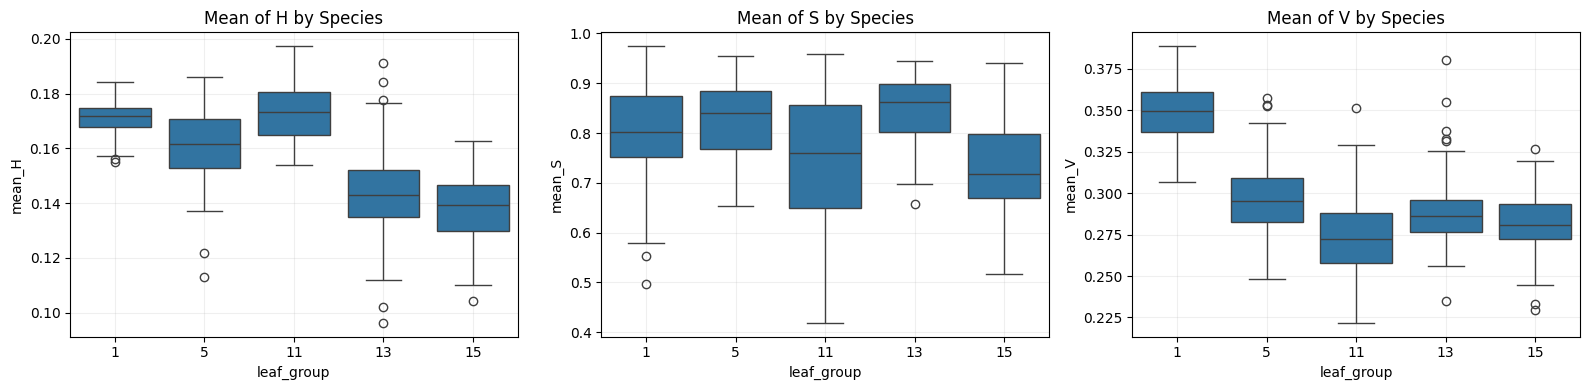

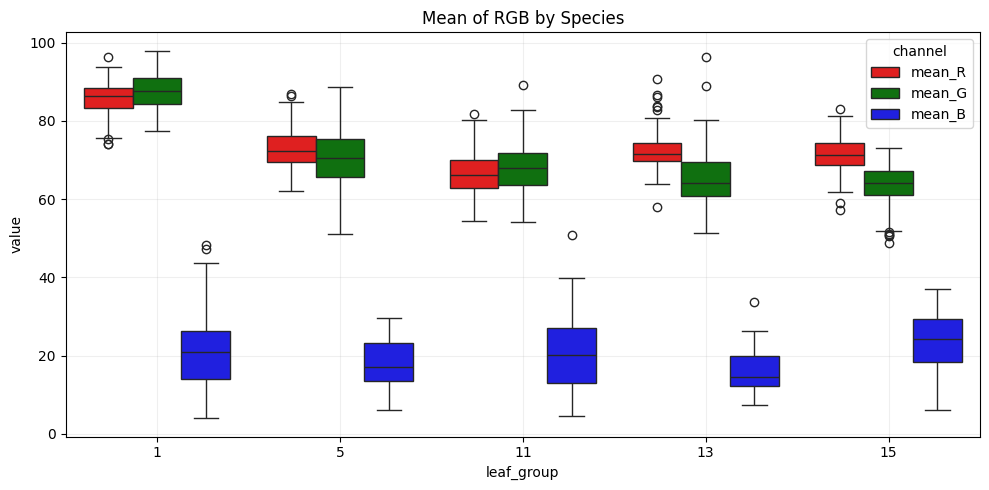

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path

species_order = [1, 5, 11, 13, 15]

if "shape_color_df" in globals():
    plot_source_df = shape_color_df.copy()
elif "color_features_df" in globals():
    plot_source_df = color_features_df.copy()
else:
    feature_path = Path("/Users/kirillburin/Desktop/STA 141B & 160/leaf_outputs/leaf_color_features.csv")
    if not feature_path.exists():
        raise FileNotFoundError("Run the color-feature cell first, or check that leaf_color_features.csv exists.")
    plot_source_df = pd.read_csv(feature_path)

plot_source_df["leaf_group"] = pd.to_numeric(plot_source_df["leaf_group"], errors="coerce")
plot_source_df = plot_source_df[plot_source_df["leaf_group"].isin(species_order)].copy()
plot_source_df["leaf_group"] = plot_source_df["leaf_group"].astype(int)
shape_color_df = plot_source_df.copy()

hsv_cols = ["mean_H", "mean_S", "mean_V"]
rgb_cols = ["mean_R", "mean_G", "mean_B"]
plot_df = shape_color_df.dropna(subset=hsv_cols)
rgb_long = (
    shape_color_df.melt(
        id_vars="leaf_group",
        value_vars=rgb_cols,
        var_name="channel",
        value_name="value"
    )
    .dropna(subset=["value"])
)

title_map = {
    "mean_H": "Mean of H",
    "mean_S": "Mean of S",
    "mean_V": "Mean of V",
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, hsv_cols):
    sns.boxplot(data=plot_df, x="leaf_group", y=col, order=species_order, ax=ax)
    ax.set_title(f"{title_map[col]} by Species")
    ax.set_xlabel("leaf_group")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=rgb_long,
    x="leaf_group",
    y="value",
    hue="channel",
    order=species_order,
    palette={
        "mean_R": "red",
        "mean_G": "green",
        "mean_B": "blue",
    }
)

plt.title("Mean of RGB by Species")
plt.xlabel("leaf_group")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

The color analysis showed that species differ not only in shape but also in color. Based on hue, Species 11 and Species 1 have the highest average hue values, while Species 13 and Species 15 have lower hue values. For saturation, Species 13 has the most vivid color on average. For the value component, Species 1 is the brightest species, whereas Species 11 is the darkest. In terms of variability, Species 11 shows relatively high variation in hue, while variation in saturation and value is higher in Species 15, Species 13, and Species 5 than in Species 11. These patterns are also supported by the RGB boxplots, which show species-level differences in the red, green, and blue channel values.

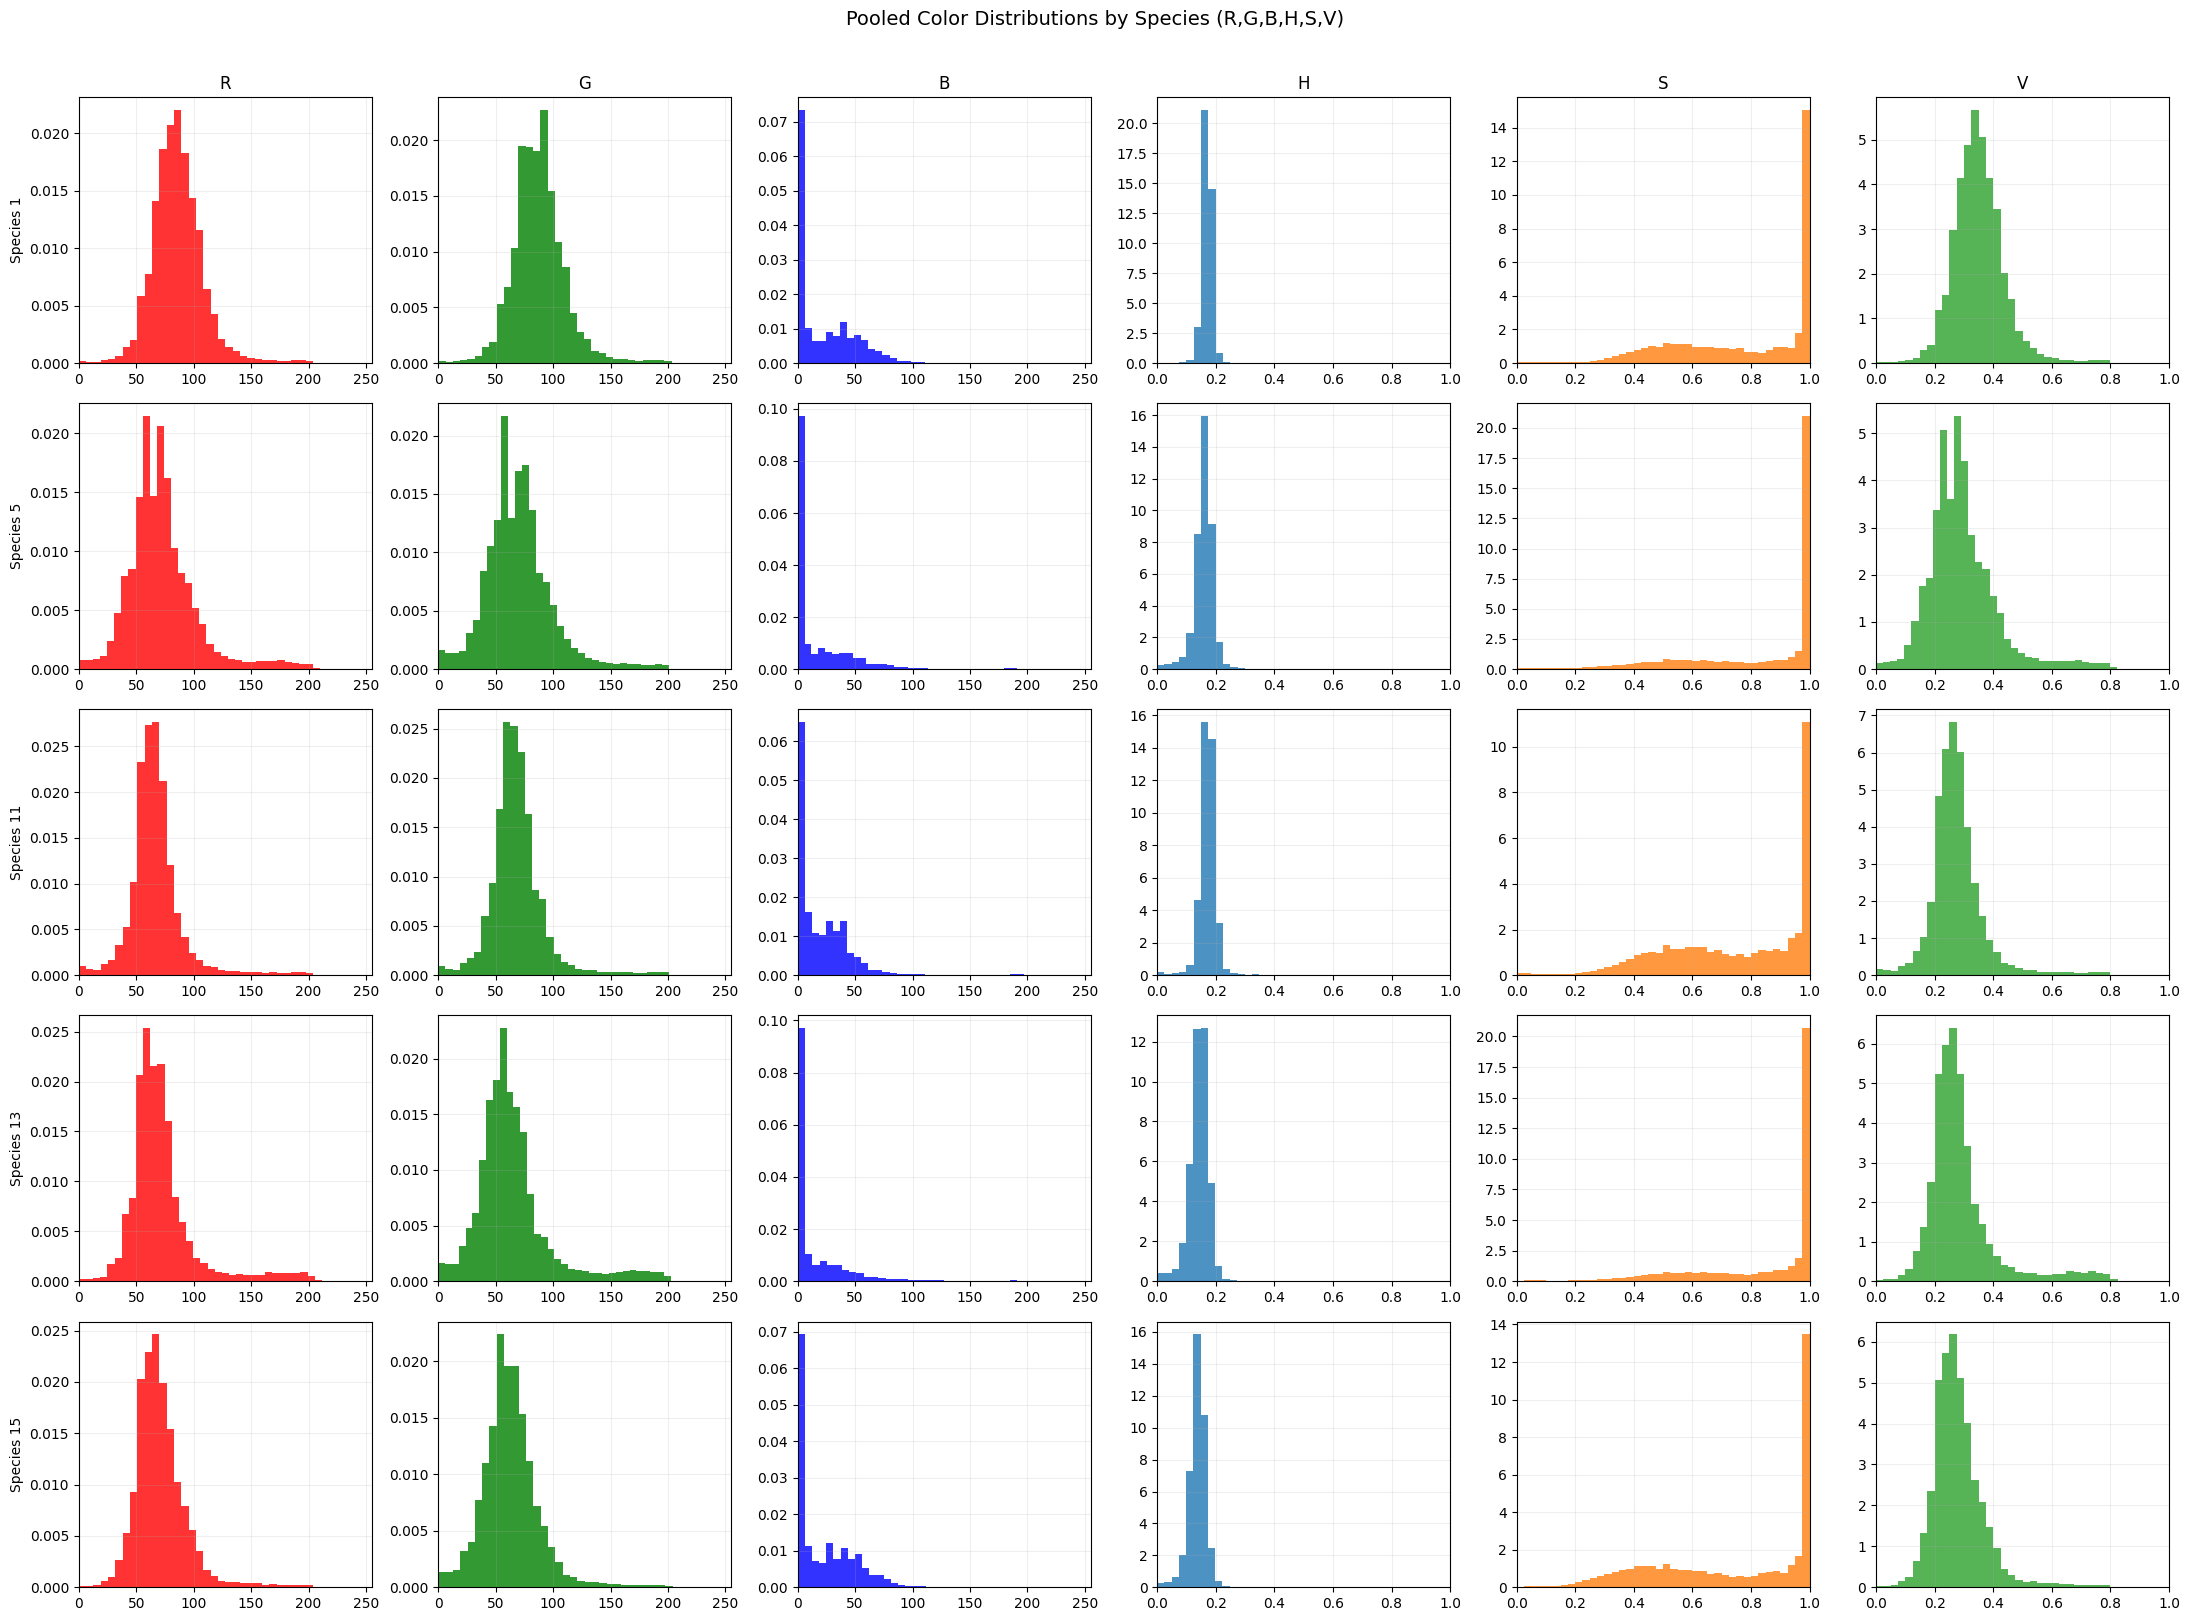

In [30]:
import numpy as np
import matplotlib.pyplot as plt

species_order = [1, 5, 11, 13, 15]
max_points_per_species = 400000  


species_pixels = {}
rng = np.random.default_rng(42)

for g in species_order:
    sub = shape_color_df[shape_color_df["leaf_group"] == g]
    R_all, G_all, B_all = [], [], []
    H_all, S_all, V_all = [], [], []

    for image_name in sub["image_name"].astype(str):
        leaf_rgb, leaf_hsv = get_leaf_pixels_rgb_hsv(image_name, threshold=200, leaf_is_dark=True)
        R_all.append(leaf_rgb[:, 0]); G_all.append(leaf_rgb[:, 1]); B_all.append(leaf_rgb[:, 2])
        H_all.append(leaf_hsv[:, 0]); S_all.append(leaf_hsv[:, 1]); V_all.append(leaf_hsv[:, 2])

    R = np.concatenate(R_all); G = np.concatenate(G_all); B = np.concatenate(B_all)
    H = np.concatenate(H_all); S = np.concatenate(S_all); V = np.concatenate(V_all)

    if len(R) > max_points_per_species:
        idx = rng.choice(len(R), size=max_points_per_species, replace=False)
        R, G, B, H, S, V = R[idx], G[idx], B[idx], H[idx], S[idx], V[idx]

    species_pixels[g] = {"R": R, "G": G, "B": B, "H": H, "S": S, "V": V}

channels = [
    ("R", "red",   (0, 255)),
    ("G", "green", (0, 255)),
    ("B", "blue",  (0, 255)),
    ("H", "tab:blue",   (0, 1)),
    ("S", "tab:orange", (0, 1)),
    ("V", "tab:green",  (0, 1)),
]

fig, axes = plt.subplots(len(species_order), 6, figsize=(22, 3.2 * len(species_order)))

for i, g in enumerate(species_order):
    for j, (ch, color, xlim) in enumerate(channels):
        ax = axes[i, j]
        ax.hist(species_pixels[g][ch], bins=40, density=True, color=color, alpha=0.8)
        ax.set_xlim(xlim)
        if i == 0:
            ax.set_title(ch)
        if j == 0:
            ax.set_ylabel(f"Species {g}")
        ax.grid(alpha=0.2)

plt.suptitle("Pooled Color Distributions by Species (R,G,B,H,S,V)", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

In [31]:
import pandas as pd

species_order = [1, 5, 11, 13, 15]

species_color_summary = (
    shape_color_df[shape_color_df["leaf_group"].isin(species_order)]
    .groupby("leaf_group", as_index=False)
    .agg(
        n=("image_name", "count"),
        mean_H=("mean_H", "mean"),
        mean_S=("mean_S", "mean"),
        mean_V=("mean_V", "mean"),
        mean_G=("mean_G", "mean"),
        std_within_H=("std_H", "mean"),
        std_within_S=("std_S", "mean"),
        std_within_V=("std_V", "mean"),
        sd_between_mean_H=("mean_H", "std"),
        sd_between_mean_S=("mean_S", "std"),
        sd_between_mean_V=("mean_V", "std"),
    )
    .set_index("leaf_group")
    .reindex(species_order)
    .reset_index())

species_color_summary = species_color_summary.round(4)

display(species_color_summary)

,leaf_group,n,mean_H,mean_S,mean_V,mean_G,std_within_H,std_within_S,std_within_V,sd_between_mean_H,sd_between_mean_S,sd_between_mean_V
0,1,75,0.1711,0.8065,0.3491,87.5567,0.0204,0.2017,0.0873,0.0064,0.1047,0.0175
1,5,75,0.1605,0.8251,0.2968,70.6835,0.0397,0.2294,0.1171,0.0132,0.0720,0.0229
2,11,75,0.1732,0.7520,0.2758,68.3746,0.0428,0.2001,0.0915,0.0109,0.1249,0.0248
3,13,75,0.1442,0.8487,0.2895,65.6945,0.0301,0.2088,0.1180,0.0165,0.0649,0.0227
4,15,75,0.1383,0.7340,0.2809,63.0242,0.0355,0.2515,0.0890,0.0122,0.0881,0.0183


In the species color analysis summaries and pooled histograms of the RGB and HSV, clear yet overlapping color differences among the five groups are observed. On average, Species 1 exhibits the brightest and greenest appearance since it has the highest mean value and average green channel (mean_V = 0.3491 and mean_G = 87.56, respectively). On the other hand, Species 11 has the lowest mean_V (0.2758) and the highest mean hue (mean_H = 0.1732) on average. Meanwhile, Species 13 and 15 have smaller mean_H values (0.1442 and 0.1383, respectively). In terms of saturation, Species 11, 13, and 15 have saturation values of mean_S = 0.7520, 0.8487, and 0.7340, respectively, with Species 13 having the highest mean_S (0.8487). However, Species 13 has a higher mean_S compared to Species 11 and Species 15. In addition, the variability measures reveal that Species 11 has the largest hue variation within leaves, as well as the largest variation of mean saturation and value between leaves, while Species 13 has the largest variation of mean hue between leaves. The histograms confirm the summaries, indicating that the species distributions are shifted differently, especially on hue, saturation, and value, yet they still overlap each other. Nevertheless, the color analysis results imply that color serves as an additional information source for differentiating species, particularly when it is combined with outlines.

## Contingency Entropothy Analysis

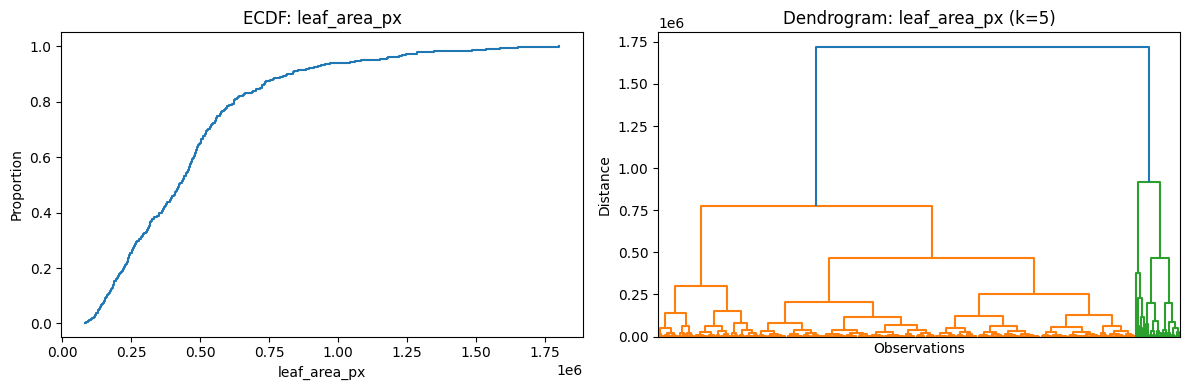


Contingency Table (counts): leaf_area_px


bin,1,2,3,4,5
leaf_group,,,,,
1,3,16,25,24,7
5,75,0,0,0,0
11,28,39,8,0,0
13,31,36,8,0,0
15,7,36,31,1,0


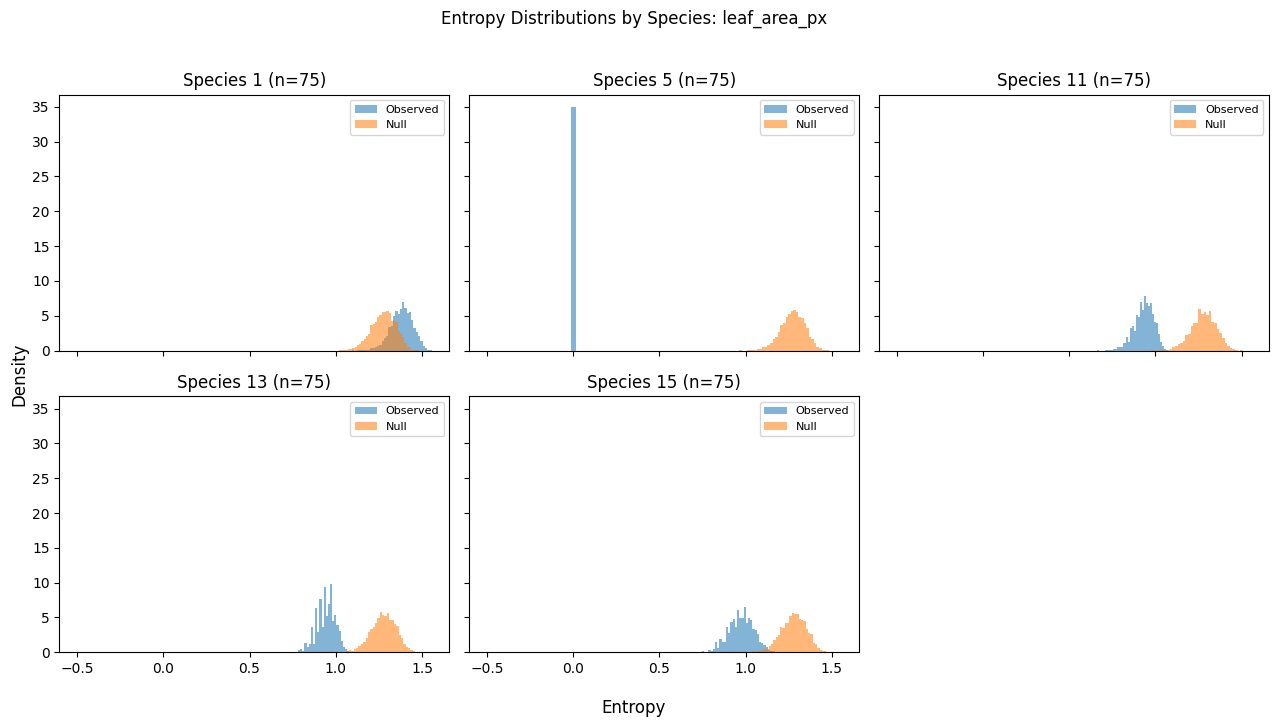

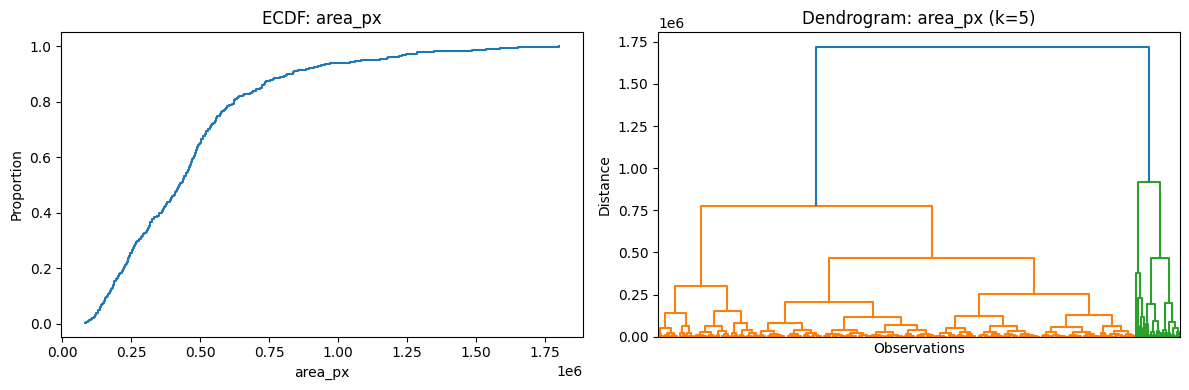


Contingency Table (counts): area_px


bin,1,2,3,4,5
leaf_group,,,,,
1,3,16,25,24,7
5,75,0,0,0,0
11,28,39,8,0,0
13,31,36,8,0,0
15,7,36,31,1,0


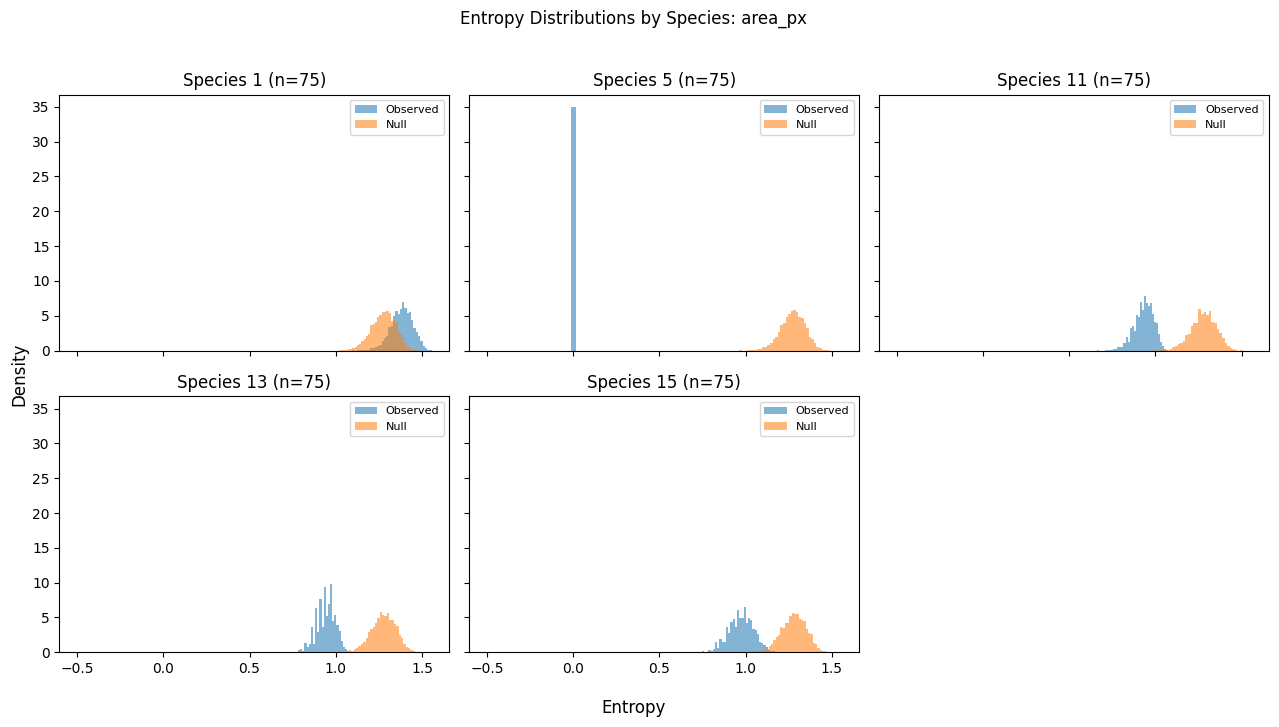

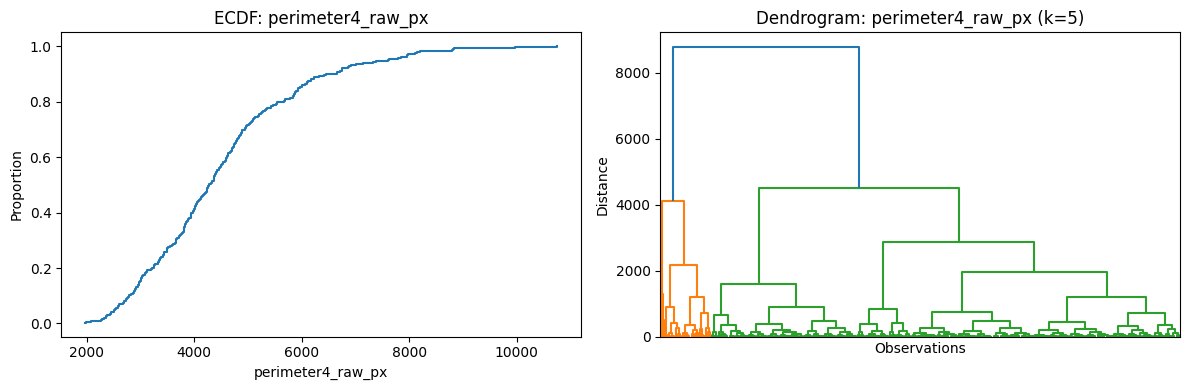


Contingency Table (counts): perimeter4_raw_px


bin,1,2,3,4,5
leaf_group,,,,,
1,2,24,19,27,3
5,73,2,0,0,0
11,20,55,0,0,0
13,1,48,19,7,0
15,9,65,1,0,0


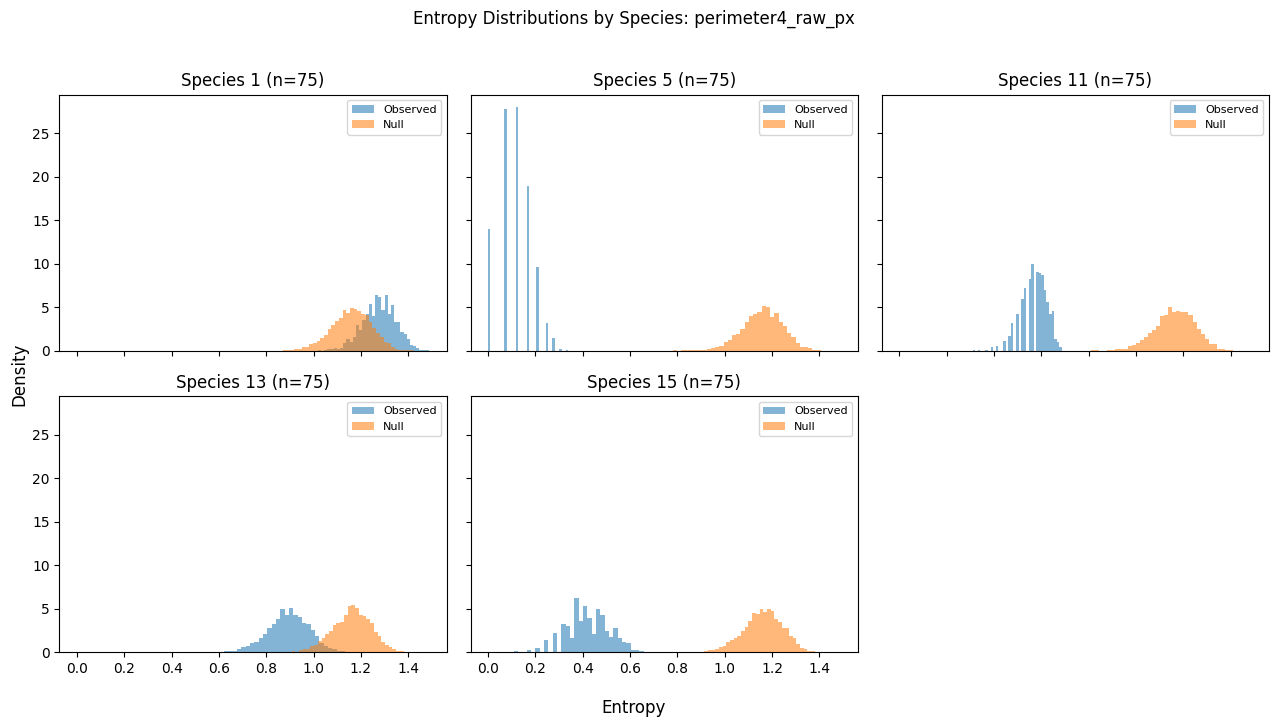

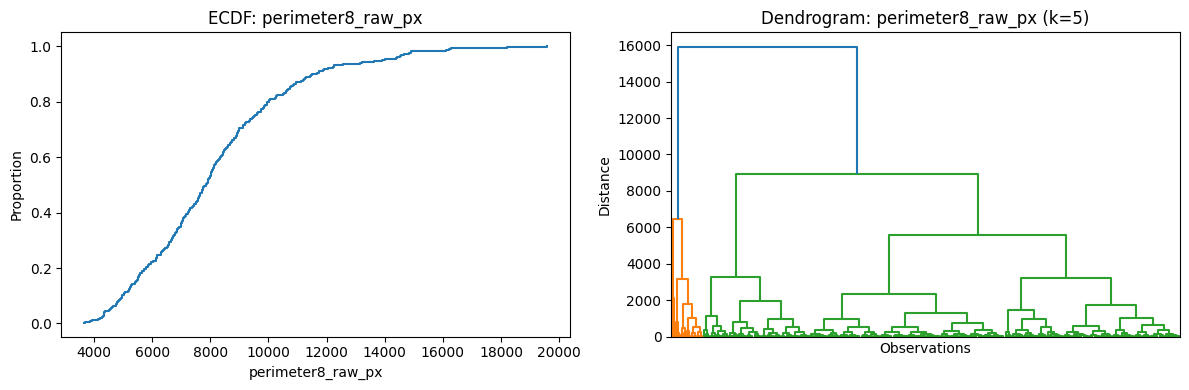


Contingency Table (counts): perimeter8_raw_px


bin,1,2,3,4,5
leaf_group,,,,,
1,4,19,29,20,3
5,74,1,0,0,0
11,26,42,7,0,0
13,11,33,30,1,0
15,14,49,12,0,0


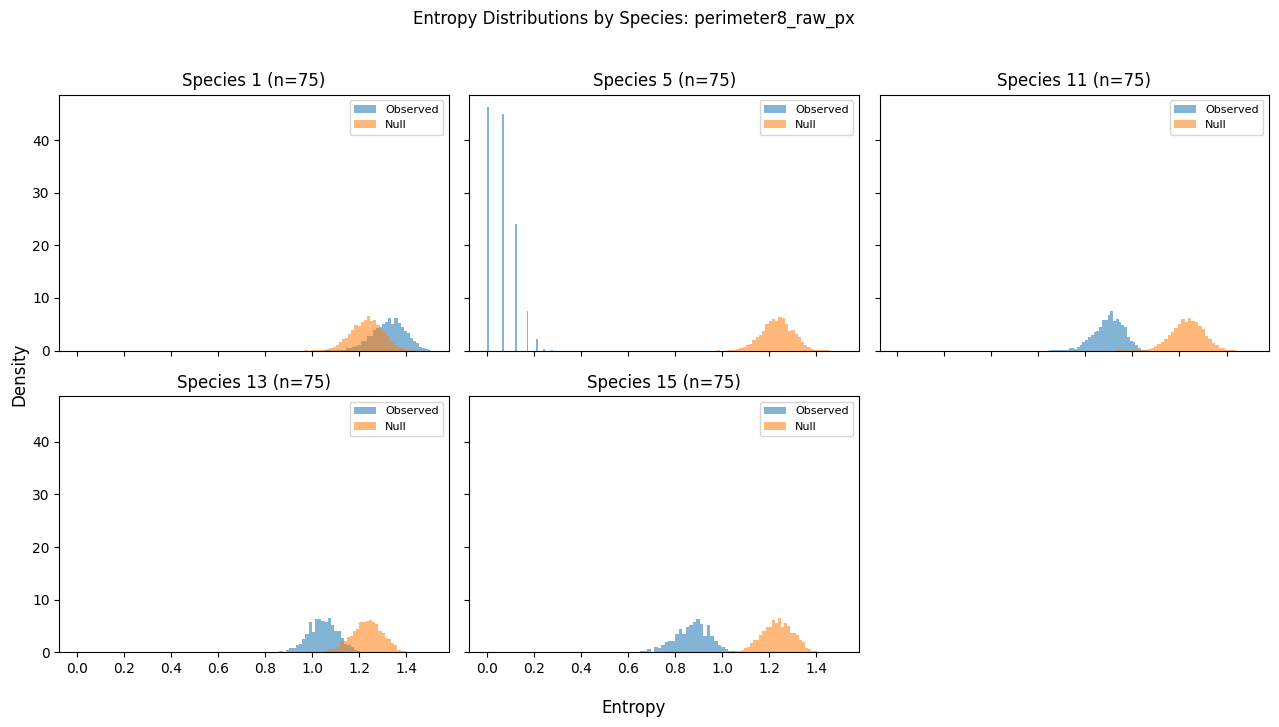

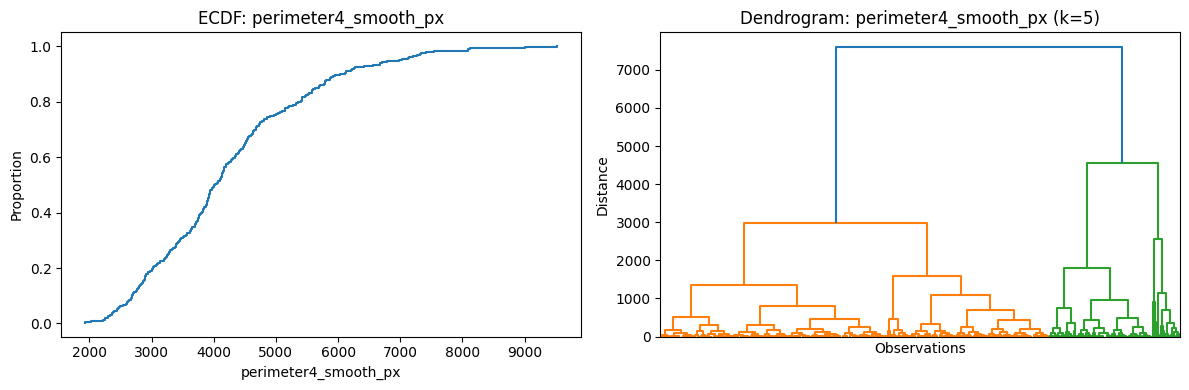


Contingency Table (counts): perimeter4_smooth_px


bin,1,2,3,4,5
leaf_group,,,,,
1,4,21,30,17,3
5,73,2,0,0,0
11,31,44,0,0,0
13,1,40,34,0,0
15,9,56,10,0,0


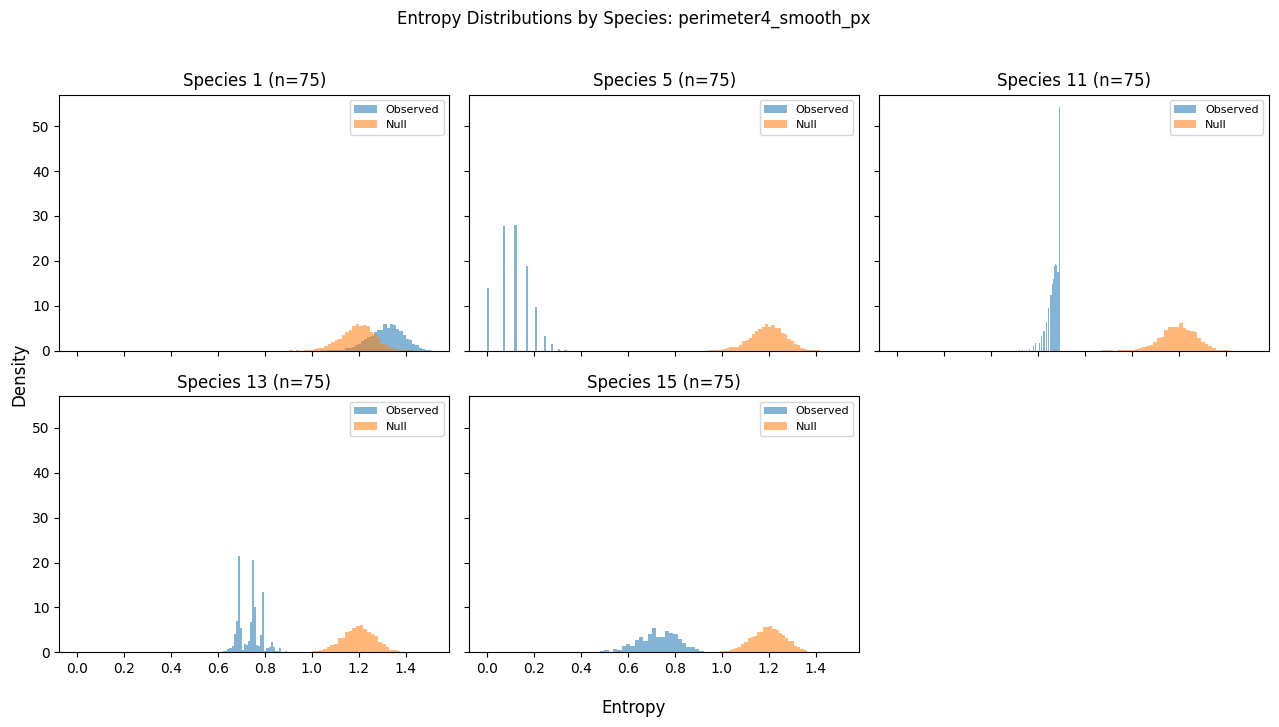

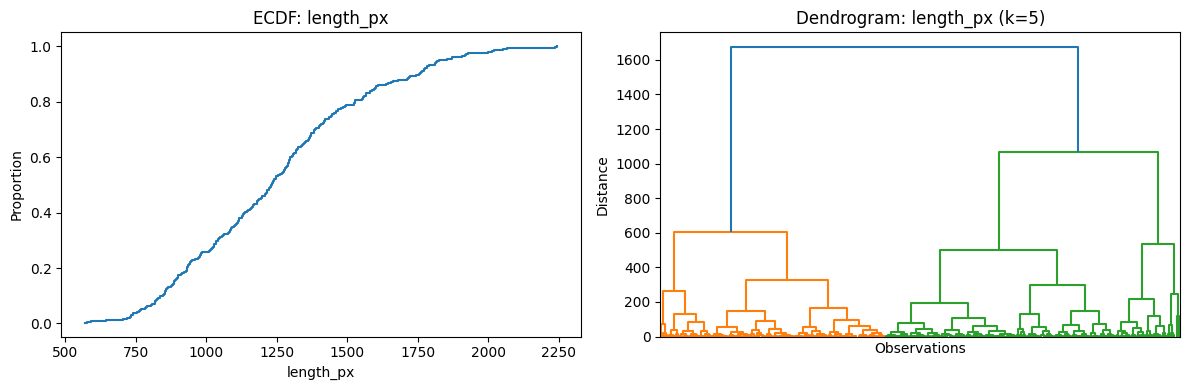


Contingency Table (counts): length_px


bin,1,2,3,4,5
leaf_group,,,,,
1,2,17,33,17,6
5,31,43,1,0,0
11,2,34,39,0,0
13,0,9,46,17,3
15,2,22,48,3,0


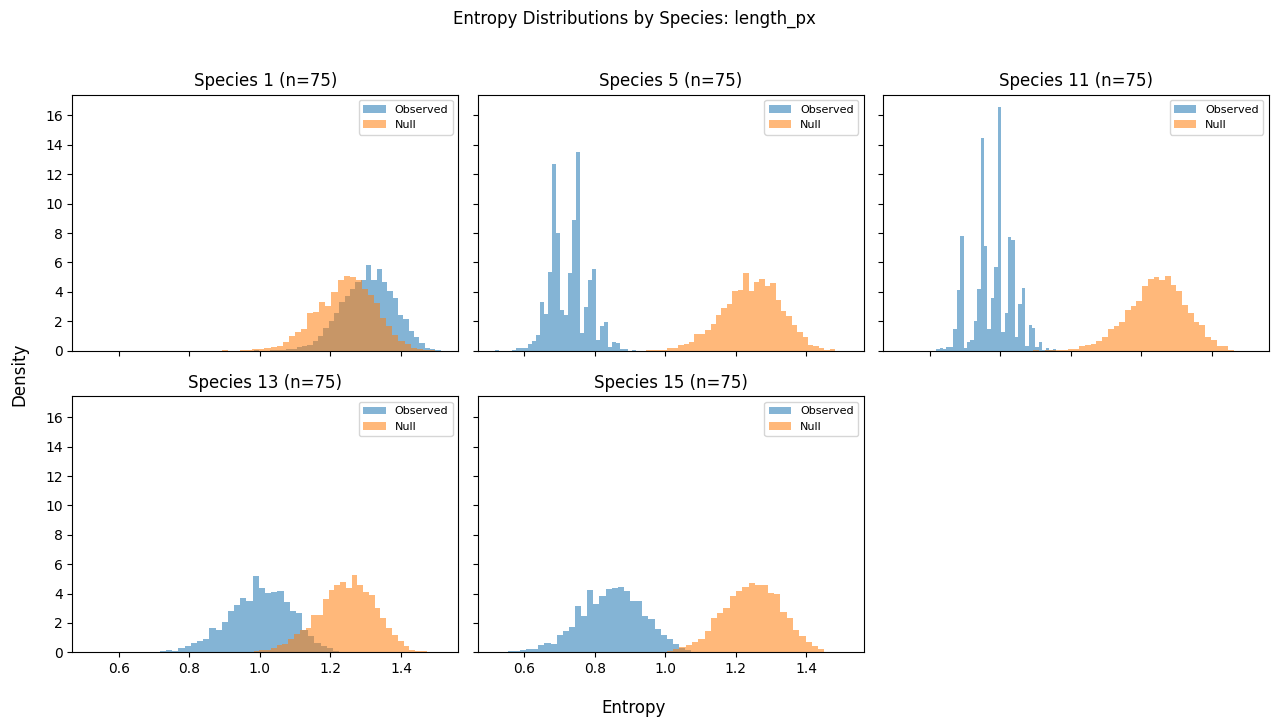

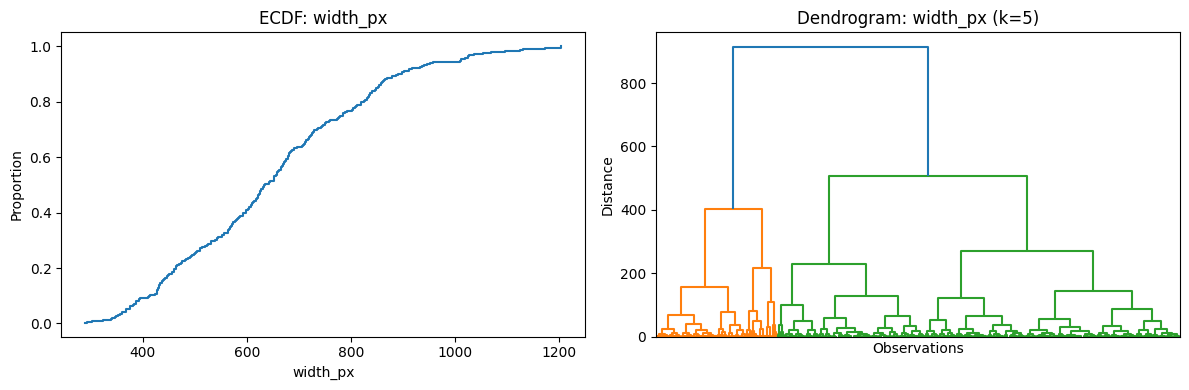


Contingency Table (counts): width_px


bin,1,2,3,4,5
leaf_group,,,,,
1,1,15,15,24,20
5,65,10,0,0,0
11,30,38,7,0,0
13,5,24,21,23,2
15,4,24,29,18,0


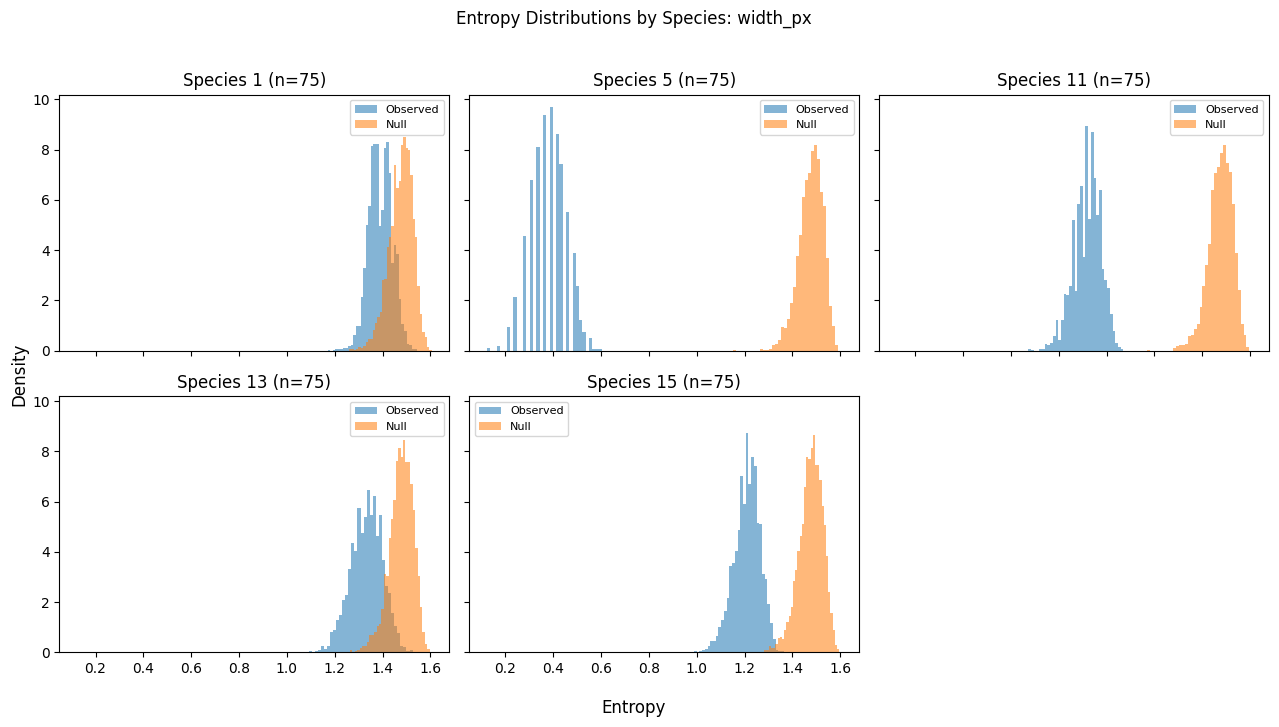

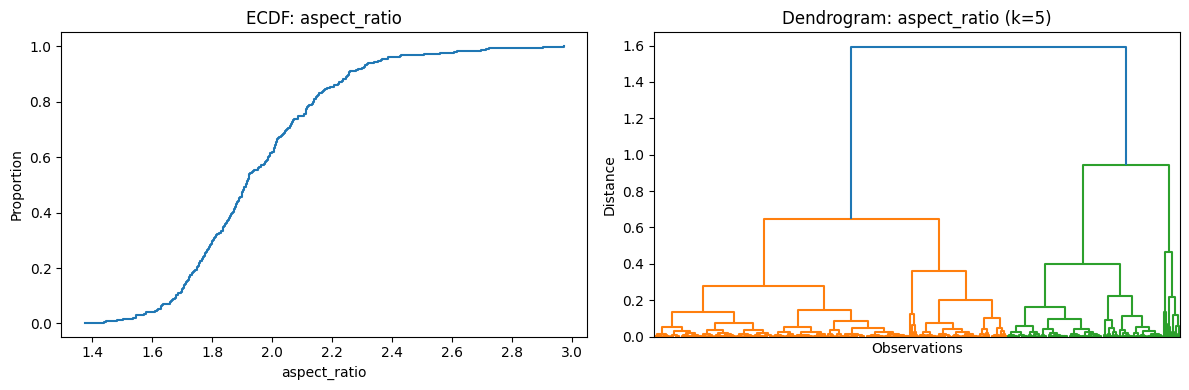


Contingency Table (counts): aspect_ratio


bin,1,2,3,4,5
leaf_group,,,,,
1,43,29,3,0,0
5,3,41,31,0,0
11,0,31,41,2,1
13,4,33,29,7,2
15,20,48,7,0,0


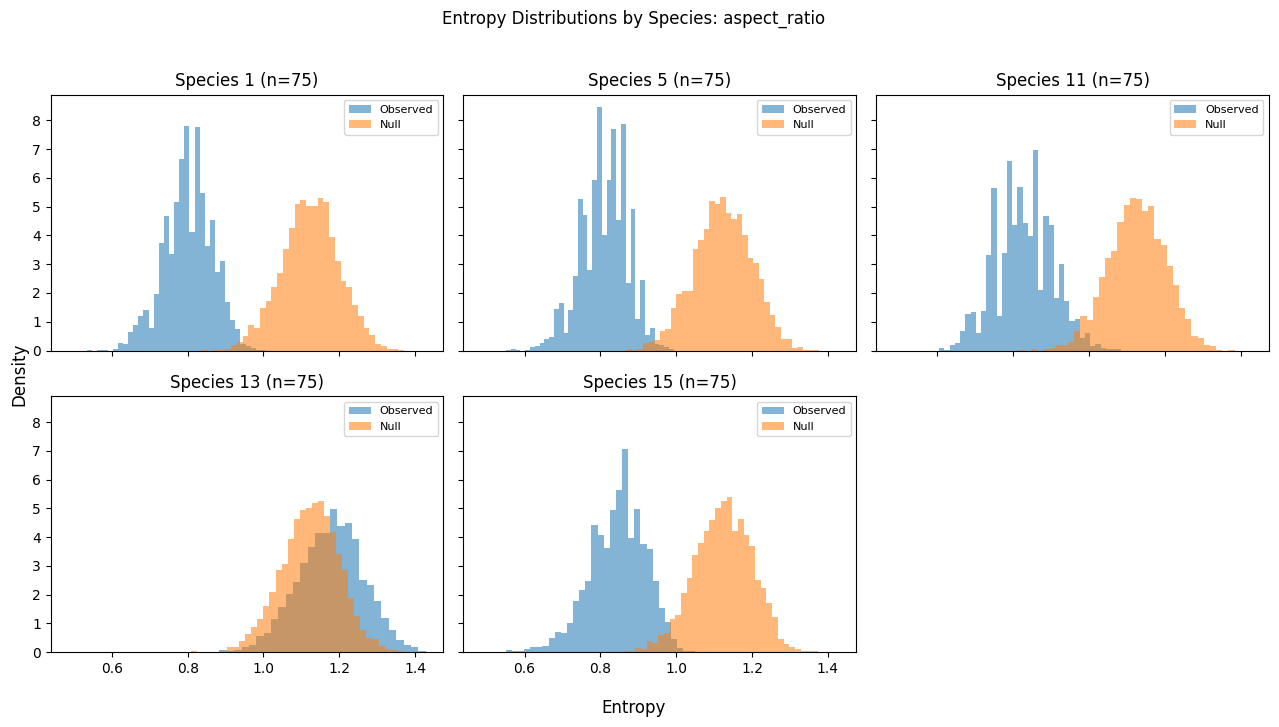

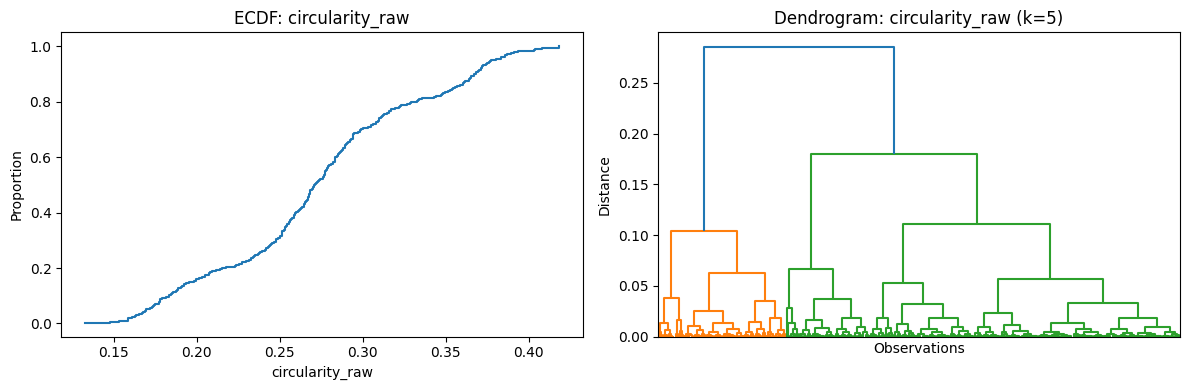


Contingency Table (counts): circularity_raw


bin,1,2,3,4,5
leaf_group,,,,,
1,1,29,42,3,0
5,0,30,44,1,0
11,0,0,62,13,0
13,59,16,0,0,0
15,0,0,0,56,19


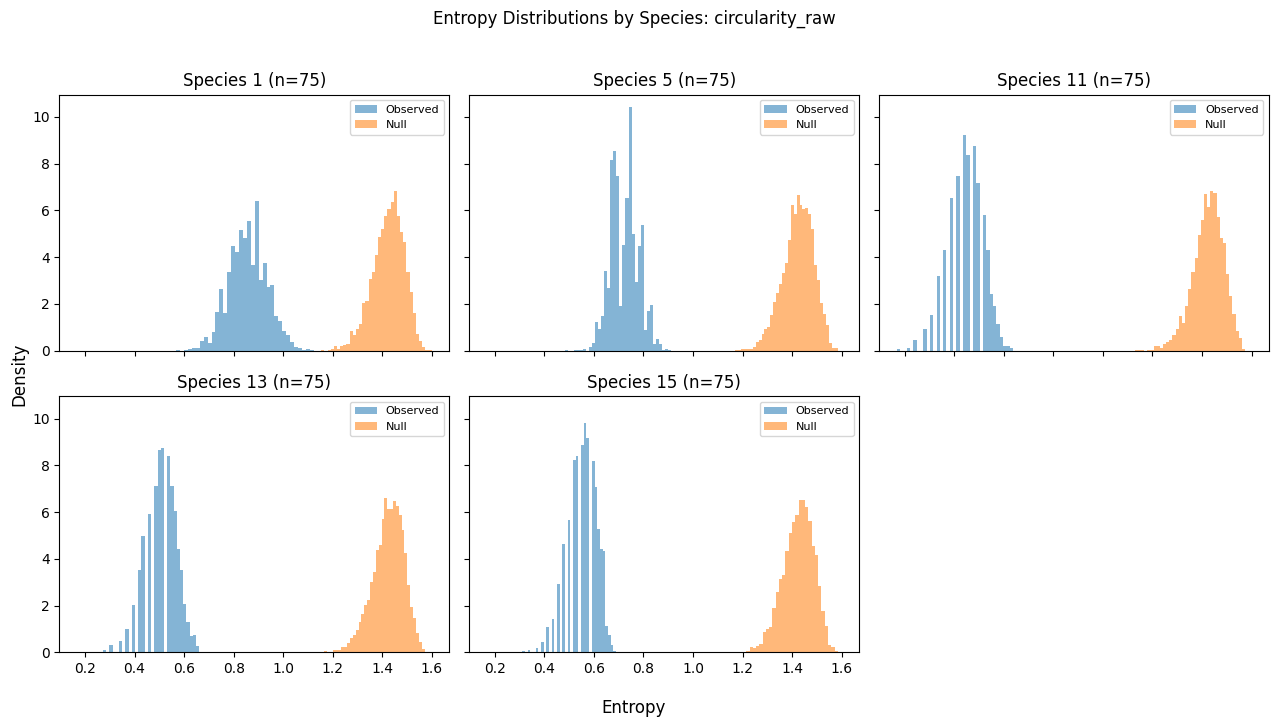

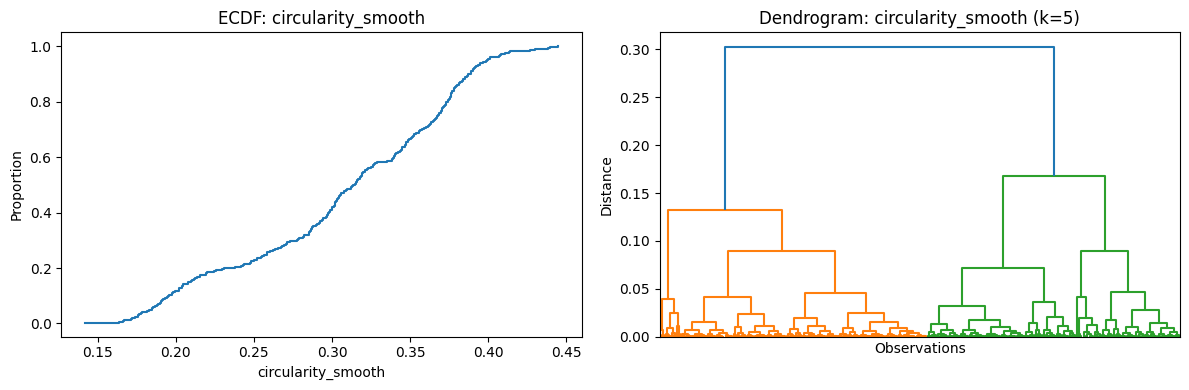


Contingency Table (counts): circularity_smooth


bin,1,2,3,4,5
leaf_group,,,,,
1,1,38,31,5,0
5,0,68,7,0,0
11,0,0,32,42,1
13,74,1,0,0,0
15,0,0,6,55,14


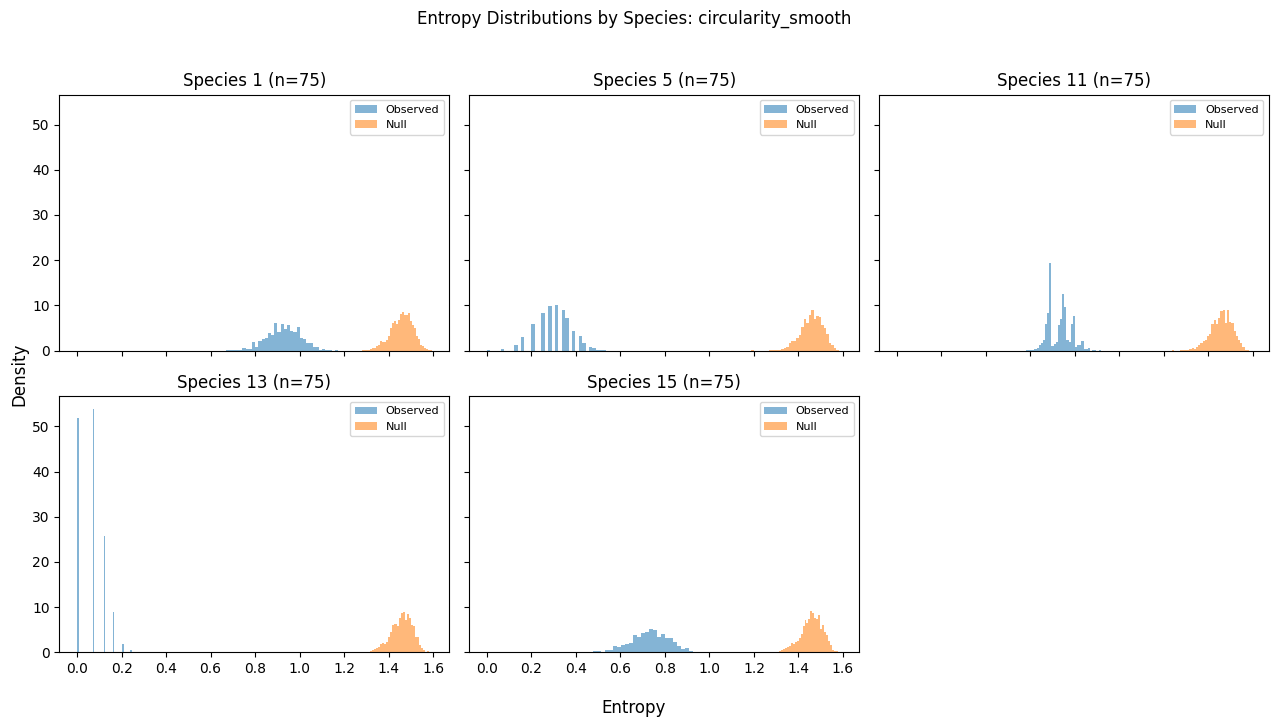

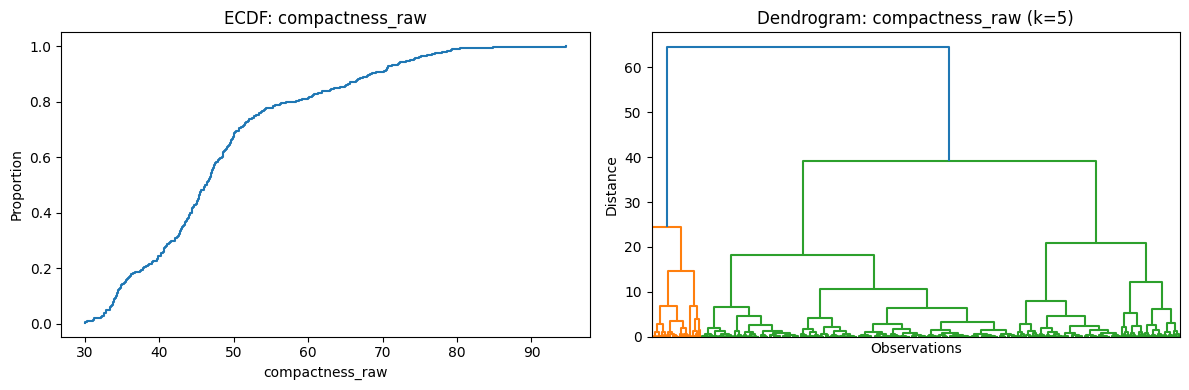


Contingency Table (counts): compactness_raw


bin,1,2,3,4,5
leaf_group,,,,,
1,36,37,1,1,0
5,41,34,0,0,0
11,72,3,0,0,0
13,0,0,41,33,1
15,75,0,0,0,0


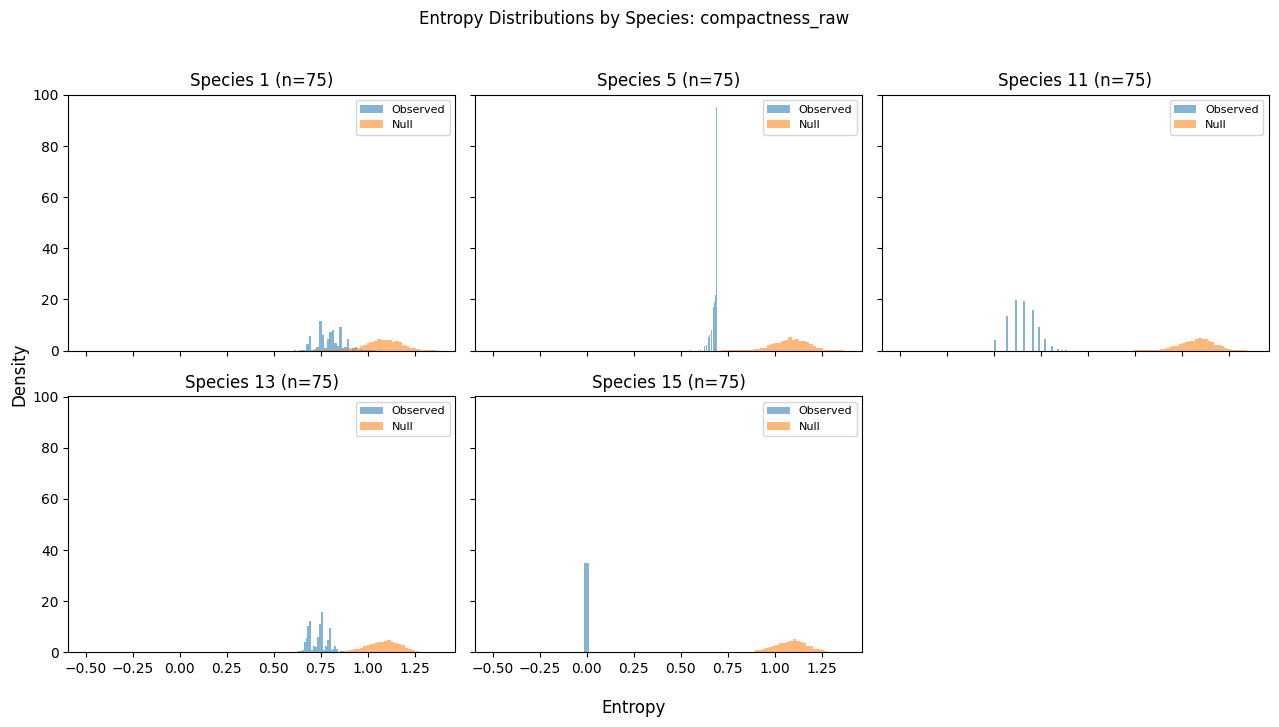

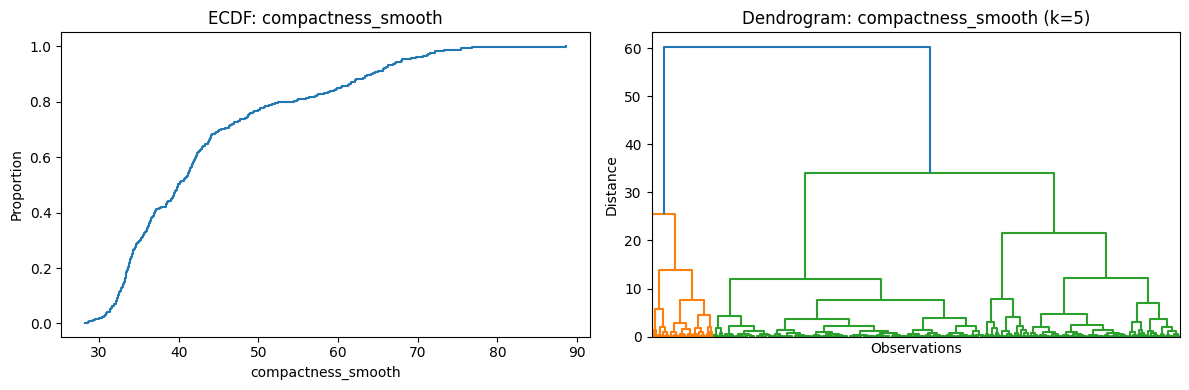


Contingency Table (counts): compactness_smooth


bin,1,2,3,4,5
leaf_group,,,,,
1,36,38,1,0,0
5,7,68,0,0,0
11,75,0,0,0,0
13,0,1,30,43,1
15,75,0,0,0,0


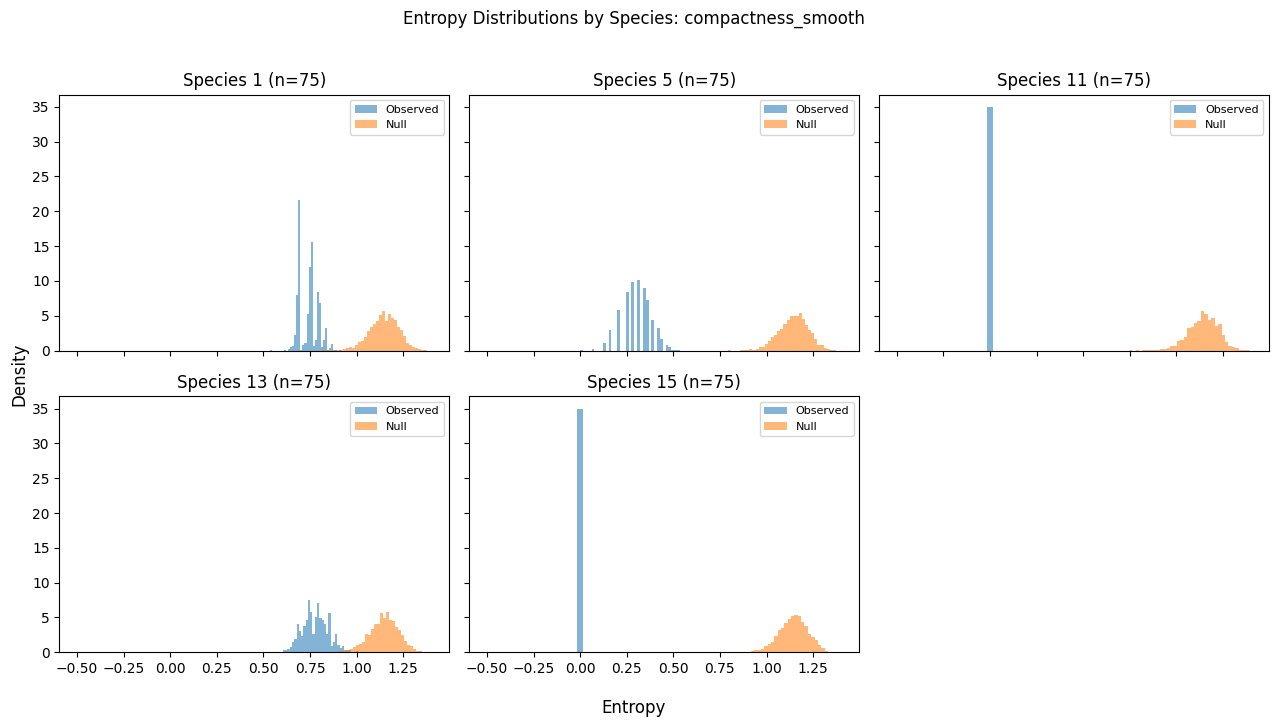

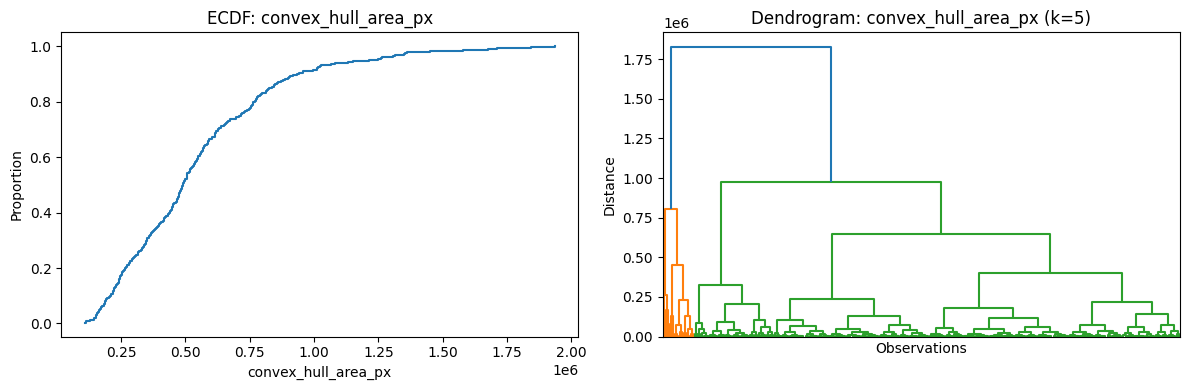


Contingency Table (counts): convex_hull_area_px


bin,1,2,3,4,5
leaf_group,,,,,
1,3,25,25,17,5
5,73,2,0,0,0
11,25,50,0,0,0
13,6,47,21,1,0
15,5,58,12,0,0


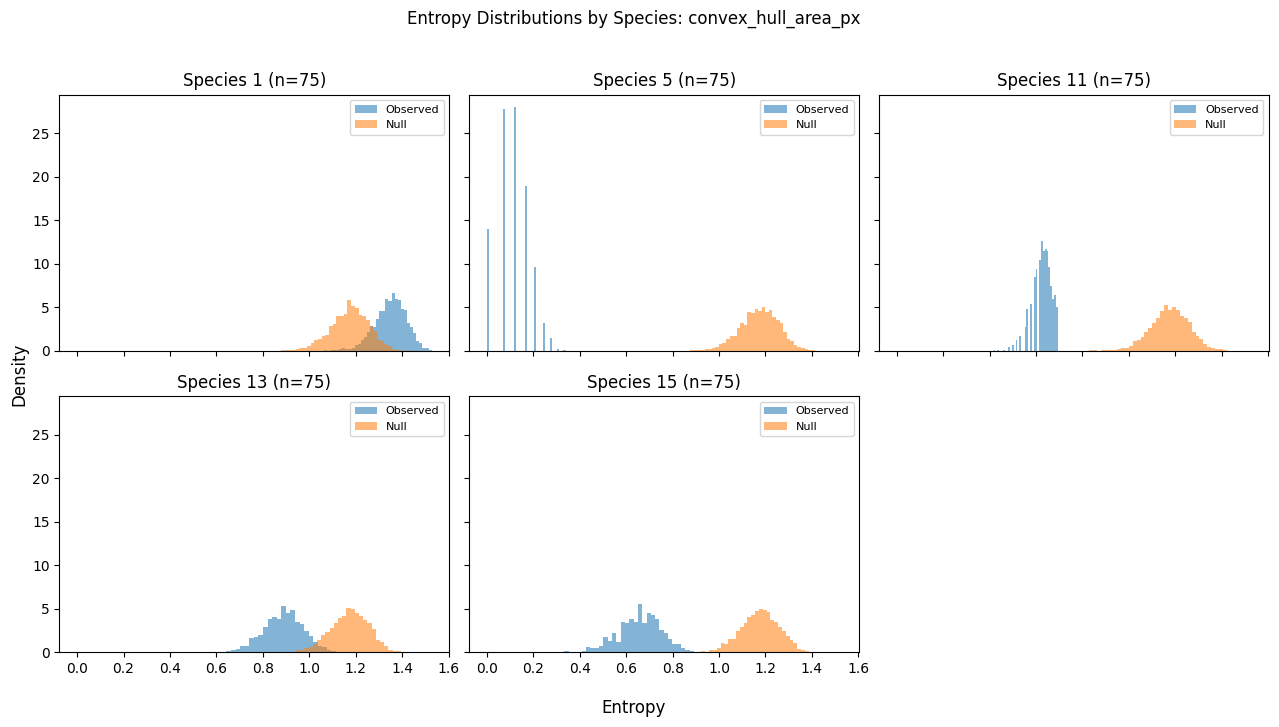

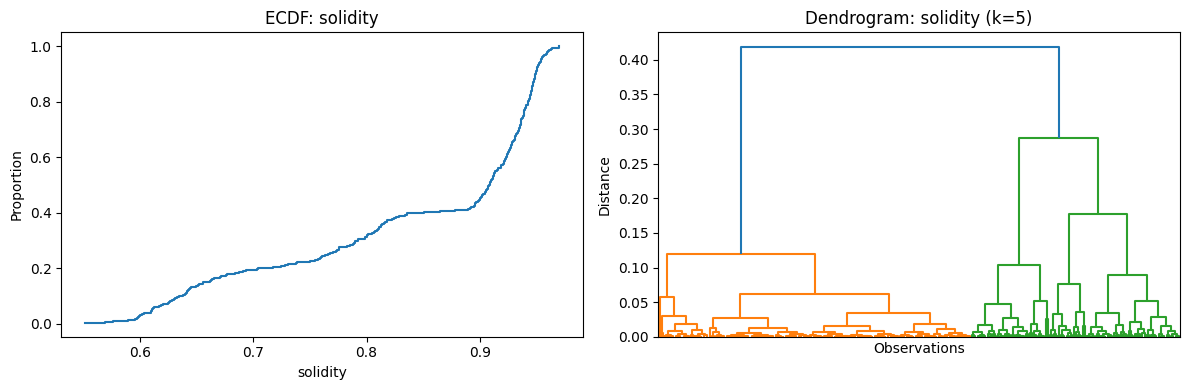


Contingency Table (counts): solidity


bin,1,2,3,4,5
leaf_group,,,,,
1,0,0,1,3,71
5,0,8,66,1,0
11,0,0,0,4,71
13,56,19,0,0,0
15,0,0,0,28,47


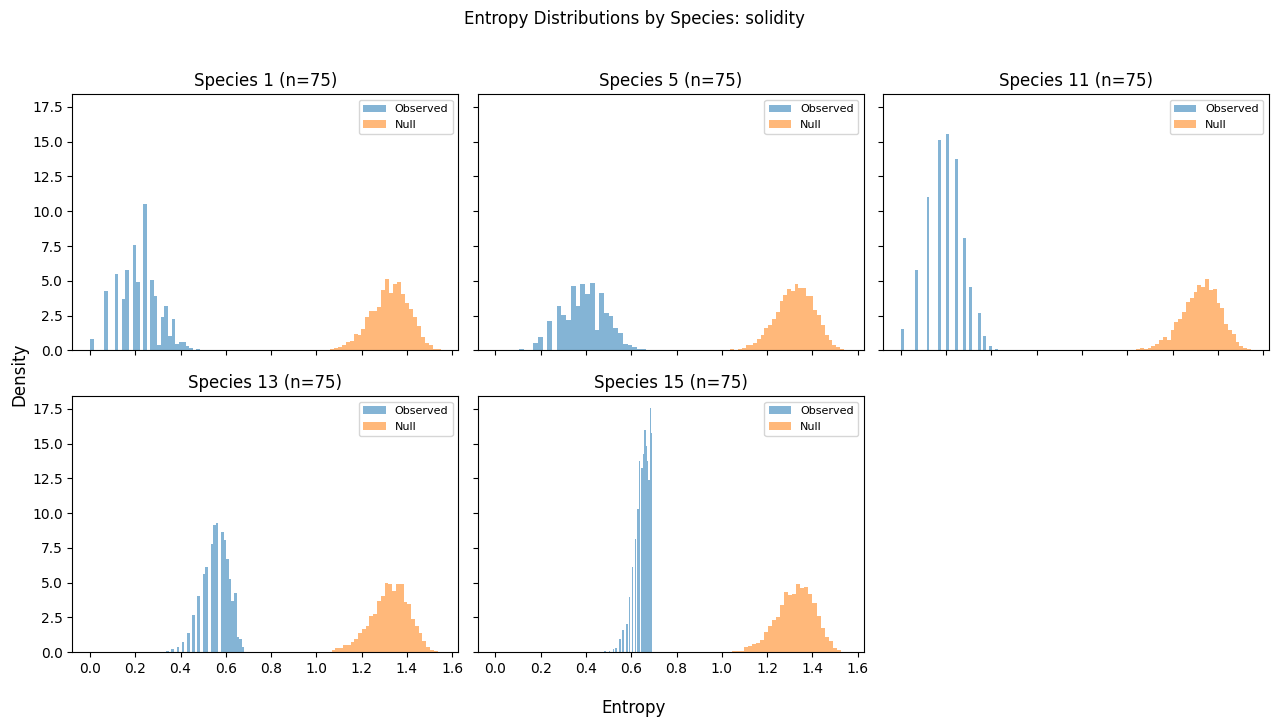

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from IPython.display import display


df = centers_with_features.copy()
species_col = "leaf_group"

exclude = {species_col, "center_x", "center_y"}
vars_all = [c for c in df.select_dtypes(include=np.number).columns if c not in exclude]


def shannon_entropy(p):
    p = np.asarray(p, dtype=float)
    p = p[p > 0]
    return -(p * np.log(p)).sum()

def simulate_entropy(n, p, B=4000, seed=141):
    rng = np.random.default_rng(seed)
    sims = rng.multinomial(n=n, pvals=np.asarray(p, dtype=float), size=B) / n
    with np.errstate(divide="ignore", invalid="ignore"):
        lp = np.where(sims > 0, np.log(sims), 0.0)
    return -(sims * lp).sum(axis=1)

def natural_clusters_1d(x, method="complete", metric="euclidean", k_fixed=5):
    Z = linkage(x.reshape(-1, 1), method=method, metric=metric)
    labels = fcluster(Z, t=k_fixed, criterion="maxclust")
    k = np.unique(labels).size
    return labels, Z, k


results = {}

for var in vars_all:
    tmp = df[[species_col, var]].dropna().copy()
    x = tmp[var].to_numpy()

    labels_raw, Z, k = natural_clusters_1d(x, k_fixed=5)
    tmp["cluster_raw"] = labels_raw


    order = tmp.groupby("cluster_raw")[var].mean().sort_values().index
    remap = {old: new for new, old in enumerate(order, start=1)}
    tmp["bin"] = tmp["cluster_raw"].map(remap)


    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    xs = np.sort(x)
    ys = np.arange(1, len(xs) + 1) / len(xs)
    ax[0].step(xs, ys, where="post")
    ax[0].set_title(f"ECDF: {var}")
    ax[0].set_xlabel(var)
    ax[0].set_ylabel("Proportion")

    dendrogram(Z, no_labels=True, ax=ax[1])
    ax[1].set_title(f"Dendrogram: {var} (k={k})")
    ax[1].set_xlabel("Observations")
    ax[1].set_ylabel("Distance")

    plt.tight_layout()
    plt.show()


    ct = pd.crosstab(tmp[species_col], tmp["bin"]).sort_index()
    print(f"\nContingency Table (counts): {var}")
    display(ct)


    p0 = (ct.sum(axis=0) / ct.values.sum()).values
    species_list = sorted(ct.index.tolist())

    fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True, sharey=True)
    axes = axes.ravel()

    for i, sp in enumerate(species_list):
        n_sp = int(ct.loc[sp].sum())
        p_alt = (ct.loc[sp] / n_sp).values

        H_alt = simulate_entropy(n_sp, p_alt, B=4000, seed=100 + i)
        H_null = simulate_entropy(n_sp, p0,   B=4000, seed=200 + i)

        axes[i].hist(H_alt, bins=35, density=True, alpha=0.55, label="Observed")
        axes[i].hist(H_null, bins=35, density=True, alpha=0.55, label="Null")
        axes[i].set_title(f"Species {sp} (n={n_sp})")
        axes[i].legend(fontsize=8)

    for j in range(len(species_list), len(axes)):
        axes[j].axis("off")

    fig.suptitle(f"Entropy Distributions by Species: {var}", y=1.02)
    fig.supxlabel("Entropy")
    fig.supylabel("Density")
    plt.tight_layout()
    plt.show()

    results[var] = {"data": tmp, "ct_counts": ct, "k": k}

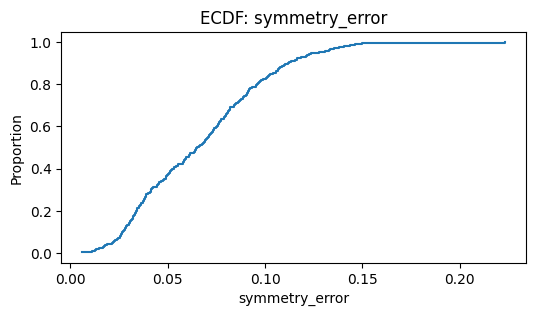

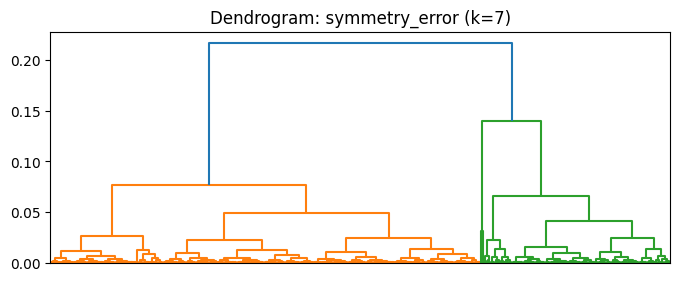

bin,1,2,3,4,5,6,7
leaf_group,,,,,,,
1,7,12,18,13,18,7,0
5,16,25,23,8,3,0,0
11,23,16,12,6,8,8,2
13,6,17,26,15,10,1,0
15,16,21,22,8,7,1,0


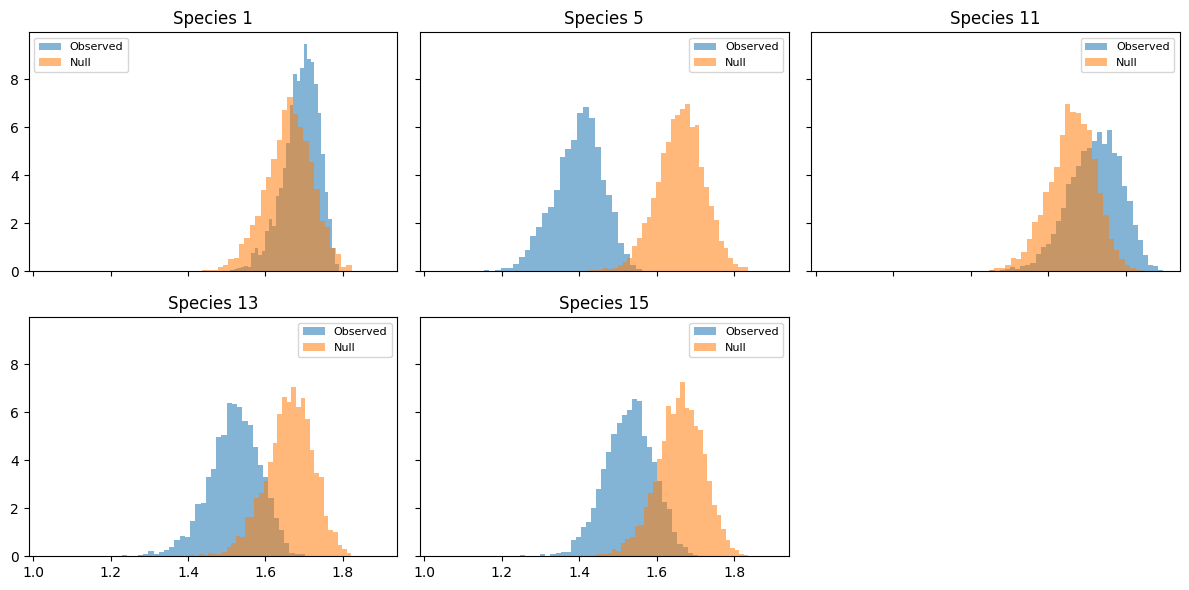


========== mean_R ==========


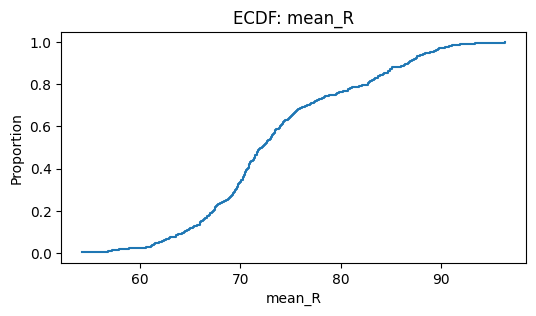

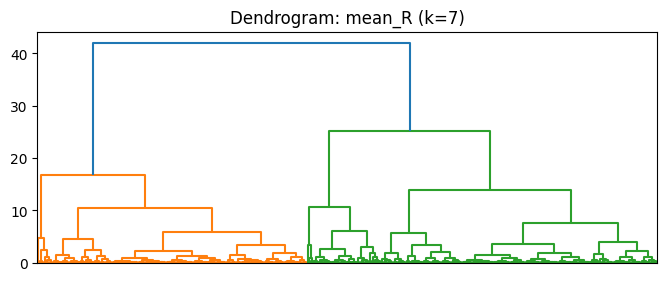

bin,1,2,3,4,5,6,7
leaf_group,,,,,,,
1,0,0,0,7,28,36,4
5,0,2,28,34,9,2,0
11,6,24,32,11,2,0,0
13,1,3,30,31,7,3,0
15,2,7,28,35,3,0,0


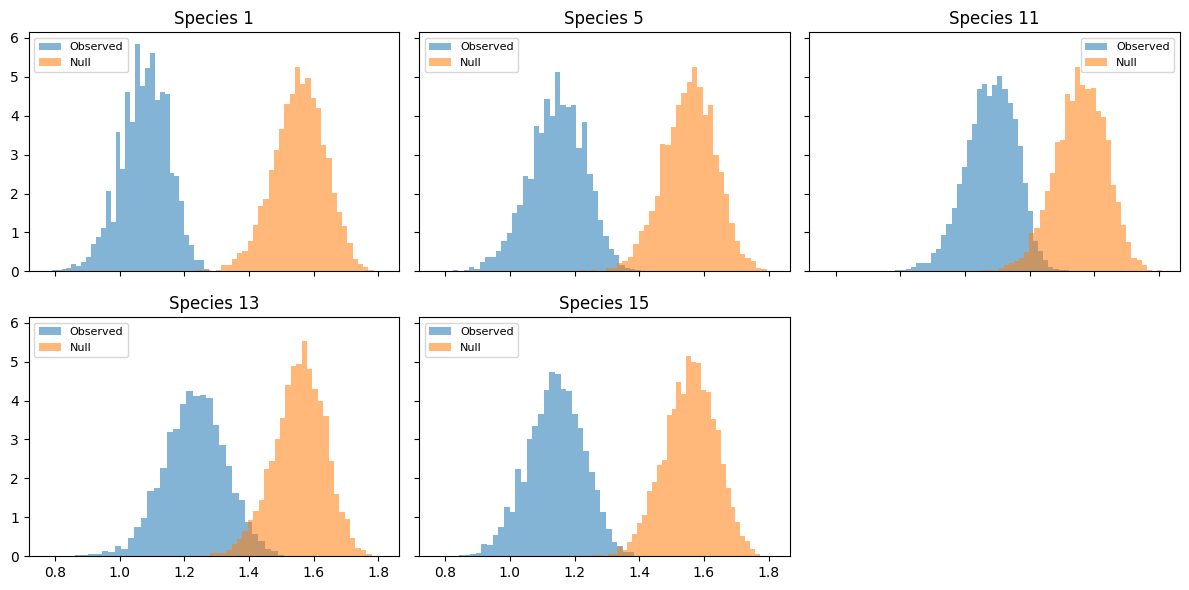


========== mean_G ==========


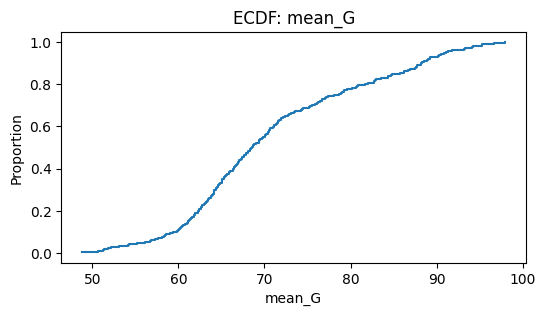

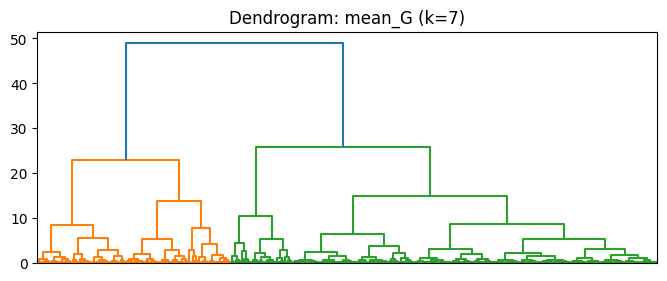

bin,1,2,3,4,5,6,7
leaf_group,,,,,,,
1,0,0,0,0,18,32,25
5,1,2,24,28,16,4,0
11,0,6,33,22,13,1,0
13,1,12,39,15,6,1,1
15,10,5,51,9,0,0,0


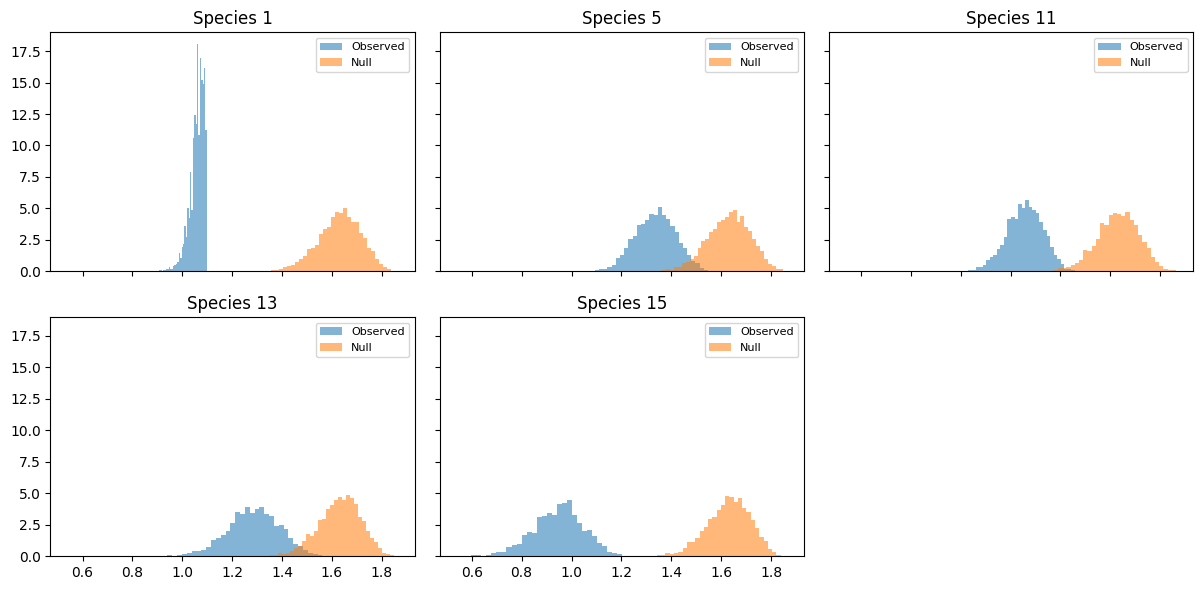


========== mean_B ==========


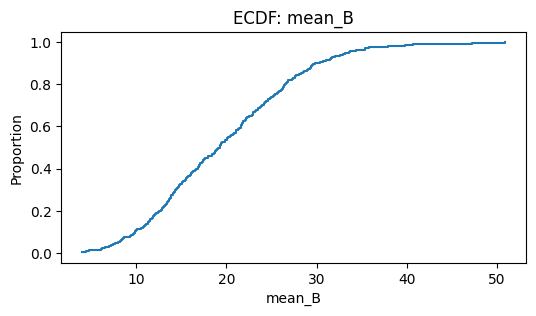

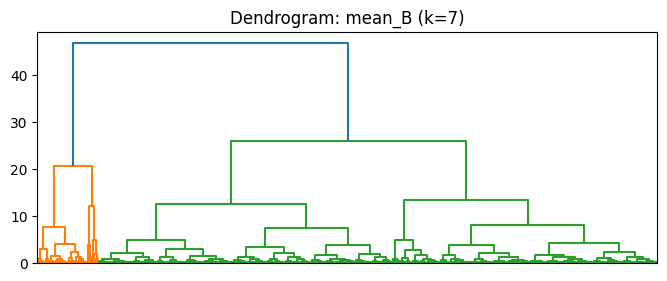

bin,1,2,3,4,5,6,7
leaf_group,,,,,,,
1,11,16,16,21,6,3,2
5,3,36,15,21,0,0,0
11,6,24,14,21,8,1,1
13,8,41,17,8,1,0,0
15,1,15,19,25,15,0,0


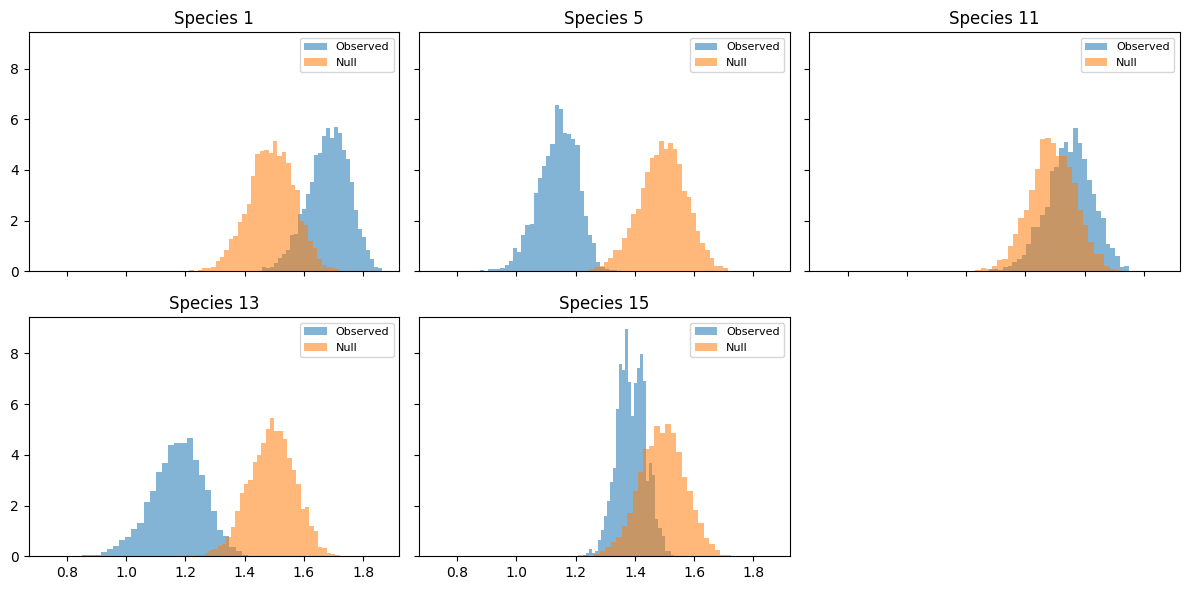


========== mean_H ==========


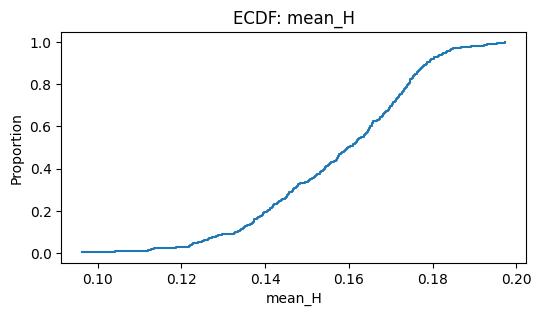

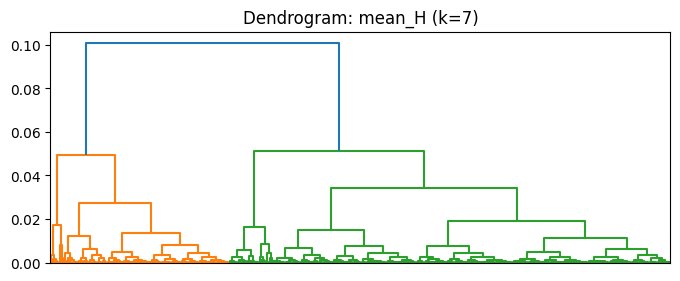

bin,1,2,3,4,5,6,7
leaf_group,,,,,,,
1,0,0,0,5,21,44,5
5,1,1,7,28,15,22,1
11,0,0,0,12,18,26,19
13,3,9,33,21,3,4,2
15,4,16,34,20,1,0,0


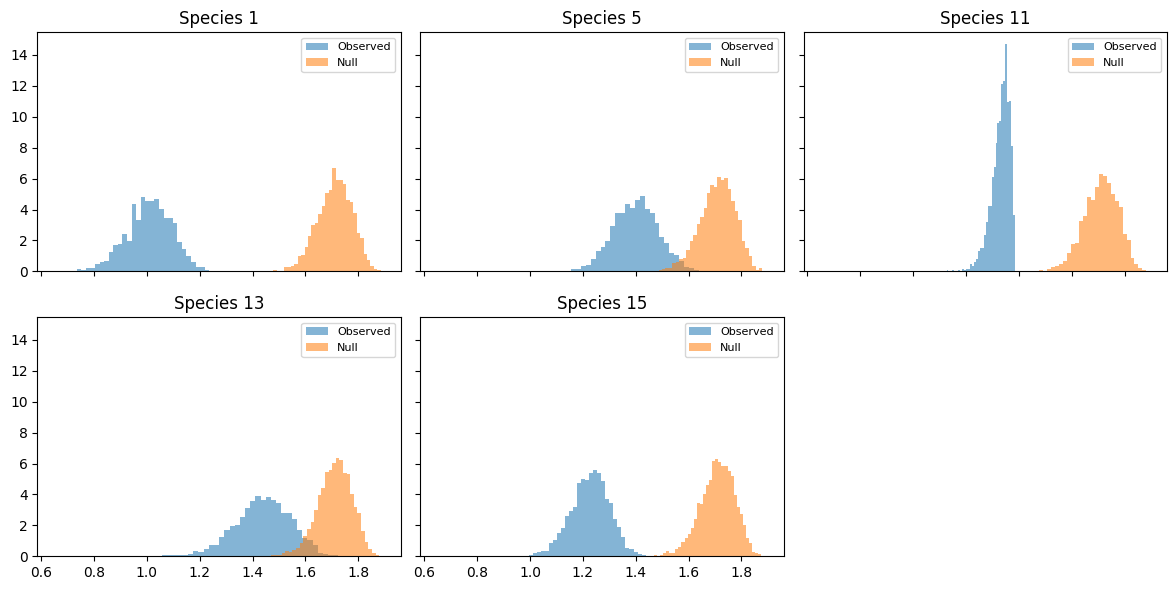


========== mean_S ==========


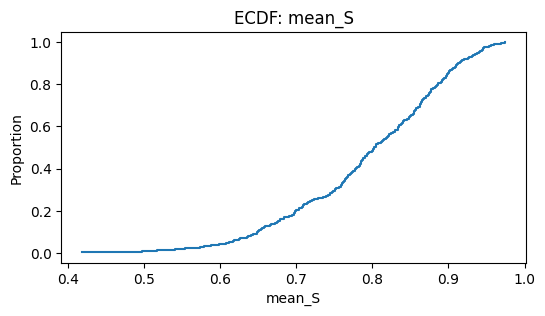

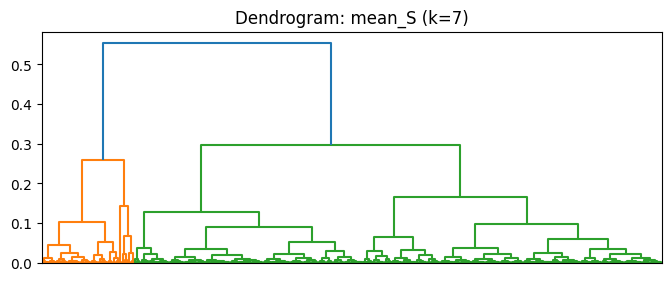

bin,1,2,3,4,5,6,7
leaf_group,,,,,,,
1,0,2,5,8,32,17,11
5,0,0,3,7,28,36,1
11,1,5,17,9,22,19,2
13,0,0,1,4,27,37,6
15,0,1,21,19,25,8,1


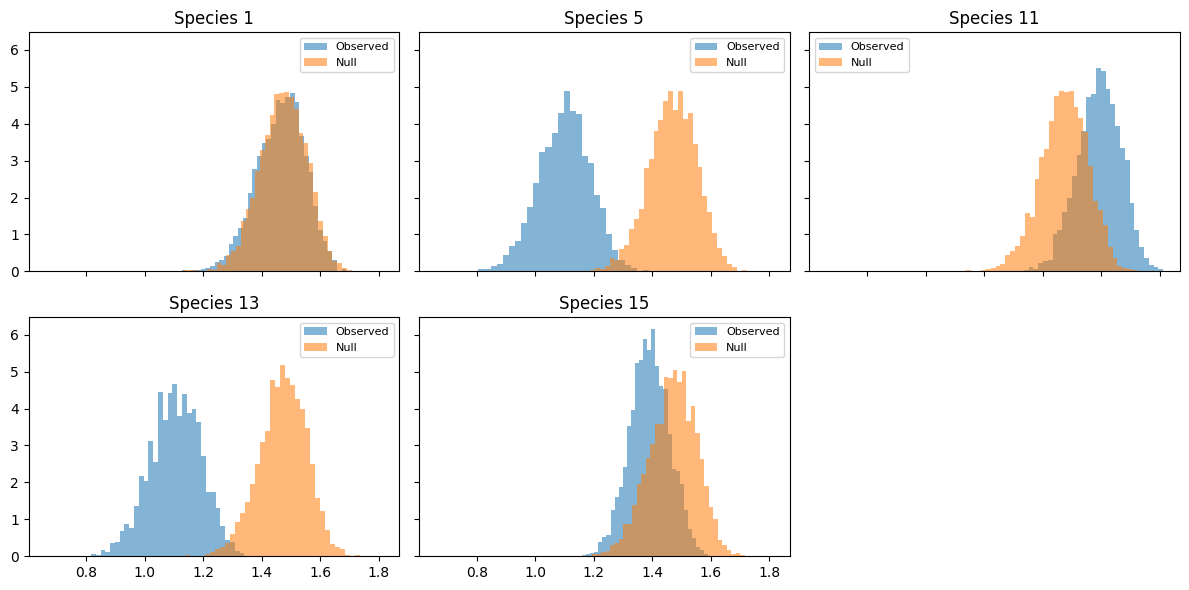


========== mean_V ==========


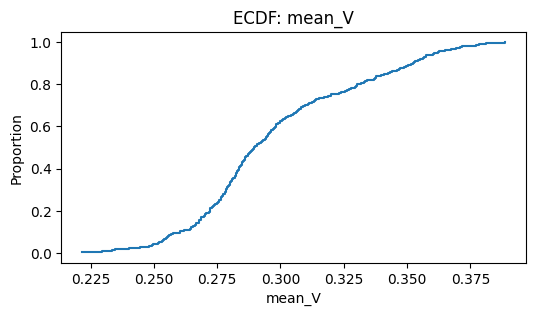

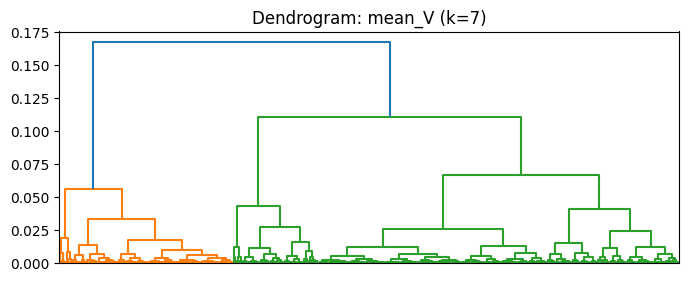

bin,1,2,3,4,5,6,7
leaf_group,,,,,,,
1,0,0,0,7,22,41,5
5,0,15,35,18,4,3,0
11,5,36,23,9,1,1,0
13,1,21,38,10,3,1,1
15,2,25,42,6,0,0,0


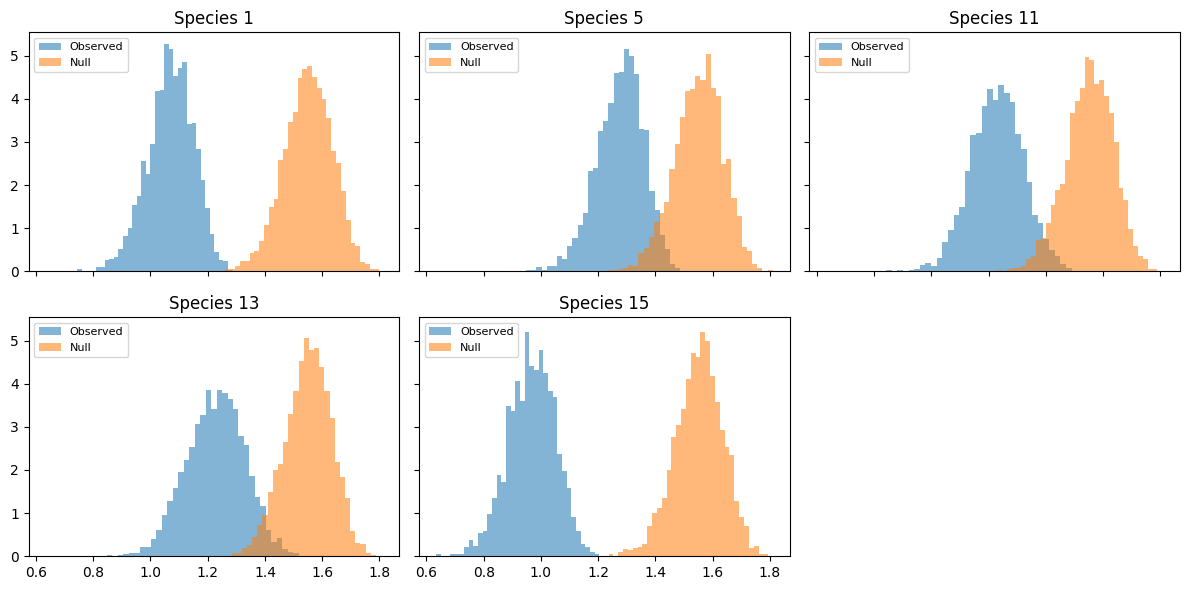

In [33]:
def run_one(df_in, species_col, var, k_fixed=7):
    tmp = df_in[[species_col, var]].dropna().copy()
    x = tmp[var].to_numpy()

    labels_raw, Z, k = natural_clusters_1d(x, k_fixed=k_fixed)
    tmp["cluster_raw"] = labels_raw


    order = tmp.groupby("cluster_raw")[var].mean().sort_values().index
    remap = {old:new for new, old in enumerate(order, start=1)}
    tmp["bin"] = tmp["cluster_raw"].map(remap)

    
    xs = np.sort(x)
    ys = np.arange(1, len(xs)+1) / len(xs)
    plt.figure(figsize=(6,3))
    plt.step(xs, ys, where="post")
    plt.title(f"ECDF: {var}")
    plt.xlabel(var)
    plt.ylabel("Proportion")
    plt.show()

    # dendrogram
    plt.figure(figsize=(8,3))
    dendrogram(Z, no_labels=True)
    plt.title(f"Dendrogram: {var} (k={k})")
    plt.show()

 
    ct = pd.crosstab(tmp[species_col], tmp["bin"])
    display(ct)

    
    p0 = (ct.sum(axis=0) / ct.values.sum()).values
    species_vals = sorted(ct.index.tolist())

    fig, axes = plt.subplots(2, 3, figsize=(12,6), sharex=True, sharey=True)
    axes = axes.ravel()

    for i, sp in enumerate(species_vals):
        n_sp = int(ct.loc[sp].sum())
        p_alt = (ct.loc[sp] / n_sp).values

        H_alt = simulate_entropy(n_sp, p_alt, B=4000, seed=100+i)
        H_null = simulate_entropy(n_sp, p0, B=4000, seed=200+i)

        axes[i].hist(H_alt, bins=35, density=True, alpha=0.55, label="Observed")
        axes[i].hist(H_null, bins=35, density=True, alpha=0.55, label="Null")
        axes[i].set_title(f"Species {sp}")
        axes[i].legend(fontsize=8)

    for j in range(len(species_vals), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

    return tmp, ct
tmp_sym, ct_sym = run_one(curve_df, "leaf_group", "symmetry_error", k_fixed=7)

mean_vars = ["mean_R", "mean_G", "mean_B", "mean_H", "mean_S", "mean_V"]

mean_results = {}

for var in mean_vars:
    print(f"\n========== {var} ==========")
    tmp_var, ct_var = run_one(
        df_in=color_features_df,
        species_col="leaf_group",
        var=var,
        k_fixed=7
    )
    mean_results[var] = {"tmp": tmp_var, "ct": ct_var}


The contingency and entropy tests were applied to determine species differences across feature-based bins. The numerical values of all outline-based features were first grouped into natural clusters, and contingency tables were then constructed to show how many leaf specimens from each species fell into each feature bin. The entropy plots were subsequently used to compare the observed entropy with the null distribution generated from the full dataset. If a species was strongly concentrated in only a few bins of a given outline feature, then its entropy was lower, indicating stronger separation for that feature. Several outline-based features, such as area, perimeter, circularity, compactness, and solidity, showed the ability to distinguish species from one another. Some species were concentrated more heavily in lower bins, while others were concentrated in higher bins. In contrast, some species were spread across many bins of a particular feature, suggesting that certain outline-based features provide better classification potential than others.



## Interpretation
In summary, the biological significance of the results seems to lie in the fact that the distinctions between the five leaf species depend not only on size, but also on leaf shape, edge roughness, and specific color properties. As for the variables related to leaf outlines, the most discriminating were found to be solidity, circularity (both raw and smoothed), and compactness (also both raw and smoothed). Biologically, these variables correspond to characteristics such as leaf roundness, compactness, and the degree of boundary irregularity. A second set of variables, such as area, perimeter, convex hull area, and width, also seemed rather significant, but with greater overlap across species. Aspect ratio can be singled out here as one of the weakest outline-based variables, thus indicating that elongation alone cannot serve as a strong criterion for separation. The present findings also confirm the usefulness of several color variables, namely V, H, G, and R, for distinguishing between species. This implies that characteristics such as leaf brightness, hue, greenness, and intensity in the red channel carry additional information beyond the leaf outline. S, B, and symmetry error turned out to be among the least discriminating variables, showing greater overlap across species.

## Prediction

Using in-memory dataframe: shape_color_df


,model,cv_acc_mean,cv_acc_std,test_acc
0,RandomForest,0.986667,0.014606,1.0
1,XGBoost,0.992000,0.006532,1.0



Best model: RandomForest

Classification report:
              precision    recall  f1-score   support

           1      1.000     1.000     1.000        15
           5      1.000     1.000     1.000        15
          11      1.000     1.000     1.000        15
          13      1.000     1.000     1.000        15
          15      1.000     1.000     1.000        15

    accuracy                          1.000        75
   macro avg      1.000     1.000     1.000        75
weighted avg      1.000     1.000     1.000        75



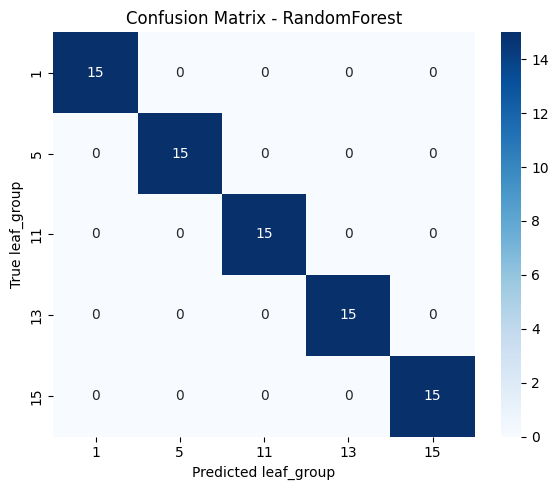

,feature,importance
0,solidity,0.129996
1,compactness_raw,0.109248
2,circularity_raw,0.102605
3,circularity_smooth,0.075828
4,std_H,0.065791
5,compactness_smooth,0.061761
6,std_R,0.053192
7,mean_G,0.044926
8,mean_H,0.043870
9,std_V,0.043459


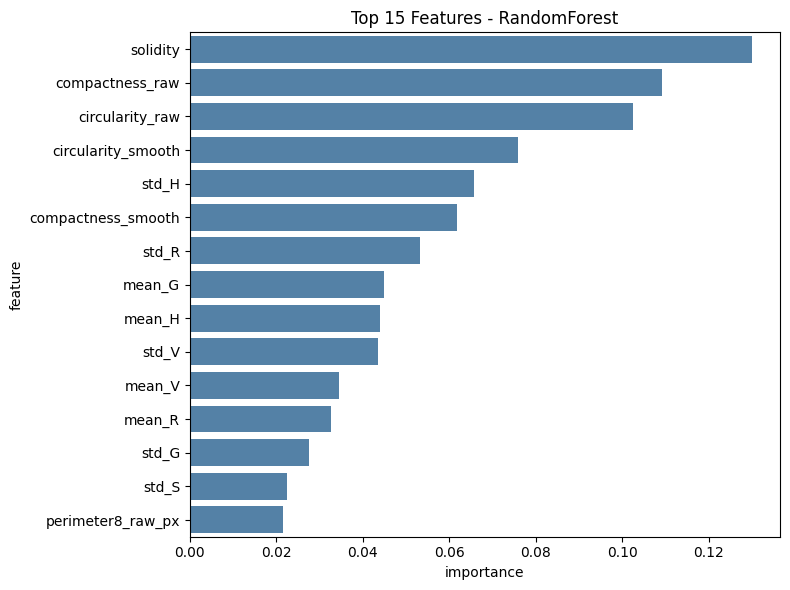

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

import pandas as pd
from pathlib import Path


for name in ["shape_color_df", "centers_with_features", "centers_df"]:
    if name in globals():
        df = globals()[name].copy()
        print(f"Using in-memory dataframe: {name}")
        break
else:
    base = Path("/Users/kirillburin/Desktop/STA 141B & 160/leaf_outputs")
    csv_candidates = [
        base / "leaf_shape_color_features.csv",
        base / "leaf_color_features.csv",
        base / "leaf_centers.csv",
    ]
    found = [p for p in csv_candidates if p.exists()]
    if not found:
        raise ValueError("No dataframe in memory and no saved CSV found in leaf_outputs.")
    df = pd.read_csv(found[0])
    print(f"Loaded from CSV: {found[0]}")


if "leaf_group" not in df.columns and "image_name" in df.columns:
    df["leaf_group"] = pd.to_numeric(
        df["image_name"].str.extract(r"(?i)^l(\d+)nr", expand=False),
        errors="coerce"
    )

species_keep = [1, 5, 11, 13, 15]
df = df[df["leaf_group"].isin(species_keep)].copy()


df["leaf_group"] = pd.to_numeric(df["leaf_group"], errors="coerce")
df = df.dropna(subset=["leaf_group"])
df["leaf_group"] = df["leaf_group"].astype(int)

drop_cols = ["leaf_group", "image_name", "center_x", "center_y"]
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in num_cols if c not in drop_cols]


if "leaf_area_px" in feature_cols and "area_px" in feature_cols:
    feature_cols.remove("leaf_area_px")

X = df[feature_cols]
y = df["leaf_group"]

le = LabelEncoder()
y_enc = le.fit_transform(y) 

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)


models = {}

rf_pipe = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(
        n_estimators=600,
        random_state=42,
        class_weight="balanced"
    ))
])
models["RandomForest"] = rf_pipe


xgb_available = False
try:
    from xgboost import XGBClassifier
    xgb_pipe = Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("clf", XGBClassifier(
            n_estimators=500,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="multi:softprob",
            eval_metric="mlogloss",
            random_state=42,
            tree_method="hist"
        ))
    ])
    models["XGBoost"] = xgb_pipe
    xgb_available = True
except Exception:
    print("XGBoost not installed -> running RandomForest only.")


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, model in models.items():
    cv_acc = cross_val_score(model, X, y_enc, cv=cv, scoring="accuracy")
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, pred)

    results.append({
        "model": name,
        "cv_acc_mean": cv_acc.mean(),
        "cv_acc_std": cv_acc.std(),
        "test_acc": test_acc
    })

results_df = pd.DataFrame(results).sort_values("test_acc", ascending=False).reset_index(drop=True)
display(results_df)

best_name = results_df.loc[0, "model"]
best_model = models[best_name]
best_model.fit(X_train, y_train)
best_pred = best_model.predict(X_test)

print(f"\nBest model: {best_name}")
print("\nClassification report:")
print(classification_report(
    le.inverse_transform(y_test),
    le.inverse_transform(best_pred),
    digits=3
))


cm = confusion_matrix(le.inverse_transform(y_test), le.inverse_transform(best_pred), labels=le.classes_)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted leaf_group")
plt.ylabel("True leaf_group")
plt.title(f"Confusion Matrix - {best_name}")
plt.tight_layout()
plt.show()


clf = best_model.named_steps["clf"]
if hasattr(clf, "feature_importances_"):
    imp = pd.DataFrame({
        "feature": feature_cols,
        "importance": clf.feature_importances_
    }).sort_values("importance", ascending=False).reset_index(drop=True)
    display(imp.head(20))

    plt.figure(figsize=(8, 6))
    sns.barplot(data=imp.head(15), x="importance", y="feature", color="steelblue")
    plt.title(f"Top 15 Features - {best_name}")
    plt.tight_layout()
    plt.show()

For the prediction step, each leaf image was represented by its extracted numerical features, and the response variable was the corresponding species label (leaf_group). Thus, the machine-learning models were trained to predict species membership from shape- and color-based leaf measurements.For the prediction step, each leaf image was represented by its extracted numerical features, and the response variable was the corresponding species label (leaf_group). Thus, the machine-learning models were trained to predict species membership from shape- and color-based leaf measurements.

Two models (Random Forest and XGBoost) were utilized to determine whether the features extracted from leaves could classify the species. Both models performed exceedingly well. Random Forest yielded a mean cross-validation accuracy of 0.9867 (std = 0.0146), whereas XGBoost yielded a mean cross-validation accuracy of 0.9920 (std = 0.0065). Both models classified 100% of the 75 test leaves correctly, indicating perfect classification of all test leaves. As the two models predicted identically on the test data, Random Forest was chosen as the model to be interpreted. The confusion matrix also showed that no leaves were classified incorrectly for any of the five species. The feature importance derived from the Random Forest further supported that the top predictors were solidity, compactness_raw, circularity_raw, and circularity_smooth, as indicated by previous results from entropy and parameter explanation. A few color features were also included as important predictors (std_H, std_R, mean_G, mean_H, std_V, mean_V, and mean_R). In summary, from the prediction results, we found that the selected outline and color features have high performance in predicting the five species.

## Conclusion
From this project, it was shown that different leaf species can be distinguished based on both outline-related and color-related properties. The most relevant variables were solidity, compactness, and circularity, since they describe leaf shape and boundary structure. Other important properties included hue, brightness, greenness, and intensity in the red channel, which provided additional information about leaf color. On the other hand, symmetry error and aspect ratio were less useful for distinguishing species because these variables showed greater overlap across groups. Overall, the most important biological differences among these species appear to be related to how rounded, smooth, compact, or irregular their leaves are. Color can also help distinguish leaves, but it is less important than leaf form.